## Assignment Overview
* This is a detection problem in this task i develop an ellipse detector:
    * for given an image, the model should detect and regress the ellipse’s parameters.
* This program is written in Python .
* data analysis:
    * label-target - imbalanced
    * ellipse size - devided into 4 class (not ellipse\small, medium, large ellipse)
    * train data was devided to 0.8/0.2 base the ellipse size estimation (axis1*axis2)
* pre-processing
    * apply modol 180 (the same ellipse)
    * images & target - normelized  ellipse coordinate (0-1)
* visualizations: 
    * example of ellipse before training
    * converge loss 
    * confusion matrix informative
    * ellipse detection on 3 data-sets
    * miss classified example from test and train
* model
    * model was desgin as CNN model with 2 outputs
        * one for classification 
        * secound for regression
* Objective
    * the objective comoused from 2 parts
        * classification loss - focal loss due to the imbalance data 
        * regession loss -L1 loss  
        * for each prediction there is equal coeeficient
        * there are spiciel case which was handle in the loss function
$$Objective =  (FL(label_p, target_t) + \sigma_1*L1loss(axis_p, axis_t) +\sigma_2*L1loss(degree_t, degree_p) + \sigma_3*L1loss(center_p, center_t))/2$$
            
        * note was tried to balance between classification task to ellipse regression
        * while the $\sigma_i$ was tried to be optimized 
Good luck!

## intstall require pakages

In [1]:
!pip install timm
!pip install torchmetrics


[notice] A new release of pip available: 22.3 -> 22.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 22.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## import pakages

In [2]:

import glob
import cv2
import numpy as np
import pandas as pd
import os 
import random
import torchvision
from collections import Counter
import itertools

from torchvision.models import efficientnet_b0
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import torchvision.transforms as transforms

from timm.data.constants import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD
from timm.data.constants import IMAGENET_INCEPTION_MEAN, IMAGENET_INCEPTION_STD
import matplotlib.pyplot as plt
plt.style.use('seaborn-white')
import seaborn as sns
sns.set_style("white")

from PIL import Image
from matplotlib import cm
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
import torch.optim as optim
from torchmetrics import F1Score
import gc
from sklearn.metrics import f1_score
gc.collect()
from PIL import Image
from torchvision import datasets, models, transforms
from torch.utils.data import Dataset
from torch.optim import lr_scheduler

import warnings
warnings.filterwarnings("ignore")
from sklearn import metrics

from torch.nn import functional as F
#image processing resources
from skimage.io import imread, imshow
from skimage.filters import gaussian, threshold_otsu
from skimage.feature import canny
from skimage.transform import probabilistic_hough_line, rotate

#testing 

from numpy import array
from numpy import argmax
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

from numpy import array
from numpy import argmax
from tensorflow.keras.utils import to_categorical

import numpy as np
import os


import time
import copy 

from shapely.geometry.point import Point
import shapely.affinity
from descartes import PolygonPatch

from torchvision import models
from torchsummary import summary

from pathlib import Path
from typing import Any, Callable, Optional
import numpy as np
from PIL import Image
from torchvision.datasets.vision import VisionDataset
# import segmentation_models_pytorch as smp
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import gc

font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 22}
import matplotlib
matplotlib.rc('font', **font)
torch.seed()

138255056493400

##  set help functions

In [3]:
def seperate_class_into_subclass(df):
    """
    seperate class's into 3 groups
    """
    elipse_estimate_size = df[' axis_1']*df[' axis_2']/(np.max(df[' axis_1'])*np.max(df[' axis_2']))
    elipse_estimate_size_copy = elipse_estimate_size.copy()
    non_ellipse = elipse_estimate_size_copy==0
    small_ellipse = (elipse_estimate_size_copy>0) & (elipse_estimate_size_copy<=0.33)
    midd_ellipse = (elipse_estimate_size_copy>0.33) & (elipse_estimate_size_copy<=0.66)
    bigg_ellipse = (elipse_estimate_size_copy>0.66) & (elipse_estimate_size_copy<=1)
    elipse_estimate_size[non_ellipse] = 0 # non elipse
    elipse_estimate_size[small_ellipse] = 1 # small ellipse
    elipse_estimate_size[midd_ellipse] = 2 # midd ellipse
    elipse_estimate_size[bigg_ellipse] = 3 # big ellipse
    df['ellipse_size_estimiation'] = elipse_estimate_size
    return df 


def generate_data_statistics(data, plot_dicreption = 'label', data_type = 'train'):
    """
    generate statistic from list of disreet ellements 
    """
    # data.sort_index()
    label_array  = np.unique(data)
    # label_array = ['False', 'True']
    amount_of_class = label_array.size
    if not isinstance(data[0], str):
        counts_train, bins_train = np.histogram(data, bins=np.arange(0, amount_of_class+1))
    else:
        counts_train = Counter(data)
        counts_train = list(counts_train.values())
        bins_train=np.arange(0, amount_of_class+1)

    bins = bins_train[0:-1]
    plt.figure(figsize=(16,18))
    plt.title(data_type+ " " + plot_dicreption, fontsize=18)
    plt.pie( counts_train, labels=bins, autopct='%3.1f%%', pctdistance=0.8, startangle=90, textprops={'fontsize': 14, 'color': 'white', 'weight':'bold'})
    plt.legend()
    return 


def split_images_path_and_label(df):
    """
    reorder dataframe
    """
    # df  = train_data_df
    df_list =  df.columns.to_list()
    images_path_label_list_column_name = df_list[0]

    images_path_label_list_column_name_list = df[images_path_label_list_column_name].tolist()
    images_path_label_list = list(map(lambda x: x.split(' '), images_path_label_list_column_name_list))
    new_columns_list =  images_path_label_list_column_name.split(': ')
    df[new_columns_list] = images_path_label_list
    df.loc[df[' angle']>180,' angle'] = df.loc[df[' angle']>180][' angle'] - 180

    return df

def generate_label_tesnor_dict(df, onehot = True):
    """
    generate on hot encofing for each class
    """
    if onehot:
        # label_list = df['is_ellipse'].unique().tolist()
        label_list = ['False', 'True']
        one_hot_encoding_tensor_list =  F.one_hot(torch.arange(0, label_list.__len__()) , num_classes=2)
        class_dict = {}
        for i_class, i_one_hot_tensor in zip(label_list, one_hot_encoding_tensor_list):
            class_dict[i_class] = i_one_hot_tensor
    else:
        label_list = df['is_ellipse'].unique().tolist()[::-1]
        class_dict = {}
        for i_class, class_idicator in zip(label_list, np.arange(0, label_list.__len__())):
            class_dict[i_class] = torch.tensor([class_idicator])
    return class_dict, label_list

def generate_elipse_polygon(bounding_box,  COLOR, factor = 1, linewidth = 2.5, linestyle = '--', label=''):
    """

    Parameters
    ----------
    generate ellipse polygon for displaying ellipse
    """
    # 1st elem = center point (x,y) coordinates
    # 2nd elem = the two semi-axis values (along x, along y)
    # 3rd elem = angle in degrees between x-axis of the Cartesian base
    ellipse = ((bounding_box[0], bounding_box[1]),(bounding_box[4],bounding_box[3]), bounding_box[2])

    # Let create a circle of radius 1 around center point:
    circ = shapely.geometry.Point(ellipse[0]).buffer(1)

    # Let create the ellipse along x and y:
    ell  = shapely.affinity.scale(circ, int(ellipse[1][0]), int(ellipse[1][1]))

    # ell  = shapely.affinity.scale(circ, int(factor), int(factor))
    # Let rotate the ellipse (clockwise, x axis pointing right):
    if ellipse[2] > 90 and 0:
        angle = ellipse[2] - 90
    else:
        angle = ellipse[2] + 90

    elrv = shapely.affinity.rotate(ell, angle)

    # Plot the ellipse
    patch = PolygonPatch(elrv, color=COLOR,  linewidth=linewidth, alpha=0.5, zorder=1, fill=False, linestyle= linestyle, label = label)
    return patch

class MyDataset(Dataset):

  def __init__(self, data_frame, transform_train, transform_test , train = True,
               debug = False, ellipse_scale = 1, scaler_operator = None):
    self.data_frame = data_frame
    self.ellipse_scale = ellipse_scale
    self.debug = debug
    self.scaler_operator = scaler_operator
    self.debug_image_idx = 0
    self.max_debug_image_allowed = 0

    if train:
        task_folder_name = 'train'
        self.transform = transform_train

    else:
        task_folder_name = 'test'
        self.transform = transform_test


    class_dict, label_list = generate_label_tesnor_dict(data_frame)
    self.label_list = label_list
    self.class_dict  = class_dict

  def __len__(self):
    return self.data_frame.shape[0]

  def __getitem__(self, idx):
    # get row from data frame
    i_row_data = self.data_frame.iloc[idx].to_list()
    # get bounding box
    bounding_box = np.array(i_row_data[1:6])

    bounding_box = self.ellipse_scale*bounding_box
    bounding_box[2]/=self.ellipse_scale
    bounding_box = bounding_box.tolist()
    # get image path
    image_path = i_row_data[6]
    full_image_path = os.path.join(main_path, image_path)
    image = Image.open(full_image_path).convert('RGB')
    single_img = self.transform(image)

    # get label
    class_indicator = i_row_data[7]
    label = class_dict[class_indicator]

    regresssion_target = torch.Tensor(bounding_box)
    # single_label = torch.concat([tensor_bounding_box, label])

    # set sample
    sample = (single_img, regresssion_target, label, full_image_path)

    if self.debug :
        # generate debug images
        fig, ax = plt.subplots()
        plt.imshow(image)
        
        # if there is bounding box plot
        if class_indicator != 'False':
            bounding_box = self.scaler_operator.inverse_transform([bounding_box])[0]
            patch = generate_elipse_polygon(bounding_box, GREEN, label = 'target')
            ax.add_patch(patch)
            

        ax.set_title(f'image_path: {image_path}\n class label: {class_indicator}\nangle {bounding_box[2]}')
        self.debug_image_idx+=1

    return sample



def predict(model, data_sizes, data_dict, scaler,  criterion_regression, criterion_classification, device, phase= 'val', debug = False):
    """


    Parameters
    ----------
    model : torch model
    data_sizes : dict of data set sizes
    data_dict : dict containig datasset
    scaler : operator to scale data
    criterion_regression : regression creterion
    criterion_classification : classification cretetion
    device : string for device type
    phase : string indicate on which data to run prediction
    debug : boolen for display images exampels for predictions

    Returns
    -------
    model : model
    epoch_loss_mse :

    """
    # Set model to evaluate mode
    model.eval()

    # get data size
    i_data_size = data_sizes[phase]

    # intilized loss
    ephoc_loss = 0.0

    # Iterate over data.
    grid_size = 3
    fig, axs = plt.subplots(grid_size,grid_size, figsize=(30, 20))
    fig.suptitle(f'results on {phase} data-set')

    class_prediction_list = []
    class_target_list = []
    regression_prediction_list = []
    regression_target_list = []
    full_path_list = []


    # set image display example index
    display_results_idx = 0
    for inputs, regression_target, label_target, file_name_list in data_dict[phase]:
        # send to device input & targets
        inputs = inputs.to(device)
        regression_target = regression_target.to(device)
        label_target = label_target.to(device)

        # forward
        with torch.no_grad():
            # model prediction and get label pred
            regression_pred, label_pred = model(inputs)

            loss = calculate_loss(model, regression_target, label_target, file_name_list, regression_pred, label_pred, criterion_regression, criterion_classification)

        # inverse ellipse to initial scale
        if device.type == 'cpu':
             reg_pred_inverse  = scaler.inverse_transform(regression_pred.detach().numpy())
             reg_target_inverse  = scaler.inverse_transform(regression_target[::,0:5].detach().numpy())
             label_pred = label_pred.detach().numpy()
             label_target = label_target.detach().numpy()

        else:
            reg_pred_inverse  = scaler.inverse_transform(regression_pred.cpu().numpy())
            reg_target_inverse  = scaler.inverse_transform(regression_target[::,0:5].cpu().numpy())
            label_pred = label_pred.cpu().numpy()
            label_target = label_target.cpu().numpy()

        # appending results
        class_prediction_list.extend(label_pred.argmax(1))
        class_target_list.extend(label_target.argmax(1))
        regression_prediction_list.extend(reg_pred_inverse)
        regression_target_list.extend(reg_target_inverse)
        full_path_list.extend(file_name_list)

        # display_results_idx = 0
        batch_size = regression_target.shape[0]
        if debug:
            for i_image_idx in range(batch_size):
                # no needed to display more images
                if display_results_idx>(grid_size*grid_size-1) and debug:
                    debug = False

                    break
                # parse target and predictions
                i_reg_pred = reg_pred_inverse[i_image_idx]
                file_name = file_name_list[i_image_idx]
                file_name_base = os.path.basename(file_name)
                i_label_pred = label_pred[i_image_idx]
                i_label_target = label_target[i_image_idx]



                # read image and display her
                image = plt.imread(file_name)
                axs[display_results_idx//3,display_results_idx%3].imshow(image)

                # display base target ellipse
                is_target = False
                if i_label_target.argmax() == 1 :
                    patch = generate_elipse_polygon(reg_target_inverse[i_image_idx], GREEN, label = 'target')
                    axs[display_results_idx//grid_size,display_results_idx%grid_size].add_patch(patch)
                    is_target = True
                # display base prdiction ellipse
                is_detect = False
                if i_label_pred.argmax() == 1:
                    patch_detectoin = generate_elipse_polygon(reg_pred_inverse[i_image_idx], RED, linestyle = '-', label = 'detection')
                    axs[display_results_idx//grid_size,display_results_idx%grid_size].add_patch(patch_detectoin)
                    is_detect = True
                axs[display_results_idx//grid_size,display_results_idx%grid_size].set_title(f'image name {file_name_base}')
                if is_detect or is_target:
                    axs[display_results_idx//grid_size,display_results_idx%grid_size].legend(loc="upper right")
                display_results_idx+=1

        # loss's
        batch_loss = loss.item()
        ephoc_loss += batch_loss*batch_size

    # calculate loss on all data
    ephoc_loss = ephoc_loss / i_data_size

    # Set model to train mode
    model.train()

    results = {    'class_prediction_list': class_prediction_list,
                   'class_target_list': class_target_list,
                   'regression_prediction_list':  regression_prediction_list,
                   'regression_target_list':regression_target_list,
                   'full_path_list': full_path_list
              }


    return model, ephoc_loss, results

def get_normelization_operator(data_train, target_columns, target_norm = 'std_mean'):
    """
    get train scale operator
    """
    
    X = data_train[target_columns].to_numpy()
    if target_norm == 'std_mean':
        scaler = StandardScaler().fit(X)
    else:
        scaler = MinMaxScaler().fit(X)


    return scaler
def apply_normelization_on_target(data, target_columns, scaler_operator):
    """
    Parameters
    ----------
    data : dataframe
    target_columns : list of target columns names
    scaler_operator : operator for scalling target

    Returns
    -------
    data : dataframe
        dataframe after normelize target columns.

    """
    X = data[target_columns].to_numpy()
    X = scaler_operator.fit_transform(X)
    data[target_columns]  = X
    return data

class EllipseDetectorModel(nn.Module):
  def __init__(self):
    super(EllipseDetectorModel, self).__init__()
    backbone  = torch.nn.Sequential(
                                    nn.Conv2d(3, 32, kernel_size=3, stride=1, padding = 'same'),
                                    nn.BatchNorm2d(32),
                                    nn.ReLU(),
                                    nn.MaxPool2d(2, 2),
                                    nn.Conv2d(32, 16, kernel_size=3, stride=1),
                                    nn.BatchNorm2d(16),
                                    nn.ReLU(),
                                    nn.MaxPool2d(2, 2),
                                    # nn.Conv2d(32, 32, kernel_size=1, stride=1, padding = 'same'),
                                    # nn.BatchNorm2d(32),
                                    # nn.ReLU(),
                                    # nn.MaxPool2d(2, 2),
                                    nn.Flatten() # size 400 after flattenning
                                    )
    classification_output  = torch.nn.Sequential(
                                                nn.Linear(1936,2),
                                                # nn.ReLU(),
                                                # nn.Linear(256,64),
                                                # nn.ReLU(),
                                                # nn.Linear(64,2),
                                                nn.Softmax()
                                                )
    regression_output  = torch.nn.Sequential(
                                           nn.Linear(1936,5)
                                           # nn.ReLU(),
                                           # nn.Linear(256,64),
                                           # nn.ReLU(),
                                           # nn.Linear(64,5)
                                            )

    self.backbone = backbone
    self.classification_output = classification_output
    self.regression_output = regression_output
  def forward(self, x):

      x = x.to(device)
      x = self.backbone(x)
      classification = self.classification_output(x)
      regression = self.regression_output(x)

      return regression, classification
  
    
class EllipseDetectorModel2(nn.Module):
  def __init__(self):
    super(EllipseDetectorModel2, self).__init__()
    backbone  = torch.nn.Sequential(
                                    nn.Conv2d(3, 32, kernel_size=3, stride=1, padding = 'same'),
                                    nn.BatchNorm2d(32),
                                    nn.ReLU(),
                                    nn.MaxPool2d(2, 2),
                                    nn.Conv2d(32, 32, kernel_size=3, stride=1),
                                    nn.BatchNorm2d(32),
                                    nn.ReLU(),
                                    nn.MaxPool2d(2, 2),
                                    nn.Conv2d(32, 16, kernel_size=1, stride=1, padding = 'same'),
                                    nn.BatchNorm2d(16),
                                    nn.ReLU(),
                                    nn.MaxPool2d(2, 2),
                                    nn.Flatten() # size 400 after flattenning 
                                    ) 
    classification_output  = torch.nn.Sequential(
                                                nn.Linear(400,128),
                                                nn.ReLU(),
                                                nn.Linear(128,2),
                                                nn.Softmax()
                                                )
    regression_output  = torch.nn.Sequential(
                                            nn.Linear(400,128),
                                            nn.ReLU(),
                                            nn.Linear(128,5)
                                            )
                
    self.backbone = backbone
    softmax = nn.Softmax(dim=0)
    self.softmax = softmax
    self.sigma = nn.Parameter(torch.ones(3))
    
    self.classification_output = classification_output
    self.regression_output = regression_output
  def forward(self, x):

      x = x.to(device)
      x = self.backbone(x)
      classification = self.classification_output(x)
      regression = self.regression_output(x)

      return regression, classification  
  
def parse_regression_predictions(pred):
    """


    Parameters
    ----------
    pred : tesnor
        model regression predictions.

    Returns
    -------
    center_cord_pred : tesnor
        center for each ellipse.
    angle_pred : tesnor
        angle for each ellipse .
    axis_pred : tesnor
        extand axis for each ellipse.
    """

    center_cord_pred = pred[::, 0:2]
    angle_pred = pred[::, 2]
    axis_pred = pred[::, 3:5]
    return center_cord_pred, angle_pred, axis_pred
class FocalLoss(nn.modules.loss._WeightedLoss):
    """
    focal loss for handle imbalance data issues
    """
    def __init__(self, weight=None, gamma=2,reduction='mean'):
        super(FocalLoss, self).__init__(weight,reduction=reduction)
        self.gamma = gamma
        self.weight = weight #weight parameter will act as the alpha parameter to balance class weights

    def forward(self, input, target):
        alpha = 0.25
        classification_loss = F.cross_entropy(input, target,reduction=self.reduction,weight=self.weight)
        pt = torch.exp(-classification_loss)
        focal_loss = (alpha*(1 - pt) ** self.gamma * classification_loss).mean()
        return focal_loss
def calculate_loss(model, regression_target, label_target, file_name_list, regression_pred, label_pred, criterion_regression, criterion_classification):
    """
    Parameters
    ----------
    regression_target : tensor
    label_target : tensor
    file_name_list : tensor
    regression_pred : tensor
    label_pred : tensor
    criterion_regression : creterion
        calculate huber loss between target and prediction of model
        to the ellipse parameters
    criterion_classification : creterion
        calculate focal loss between target and prediction of model if
        there is ellipse or not
    Returns
    -------
    loss value
    """
    # get mask where there is ellipse
    is_ellipse_mask = (label_target[:,1]>0).squeeze()

    # get ellipse rellevant regression pred
    if device.type == 'cpu':
        is_ellipse_mask = is_ellipse_mask.detach()
    else:
        is_ellipse_mask = is_ellipse_mask.cpu()
    ellipse_regression_pred = regression_pred[is_ellipse_mask]
    ellipse_regression_target = regression_target[is_ellipse_mask]
    ellipse_name_list = np.array(file_name_list)[is_ellipse_mask]

    if ellipse_regression_pred.shape[0] == 0: # if all data is not ellipse, calculate only the criterion_classification
        classification_loss = criterion_classification(label_pred, label_target.to(torch.float))
        return classification_loss

    # parse results
    center_cord_pred, angle_pred, axis_pred = parse_regression_predictions(ellipse_regression_pred)
    center_cord_target, angle_target, axis_target = parse_regression_predictions(ellipse_regression_target)

    # get not circle index
    not_circle_mask = (torch.abs(axis_target[:,0]-axis_target[:,1])>0.05) #
    if device.type == 'cpu':
        not_circle_mask = not_circle_mask.detach()
    else:
        not_circle_mask = not_circle_mask.cpu()

    ellipse_angle_pred = angle_pred[not_circle_mask]
    ellipse_angle_target = angle_target[not_circle_mask]
    # check if there is no needed to caluclate angle loss
    if ellipse_angle_pred.shape[0] ==0:
        angle_loss = 0
    else:
        angle_loss = criterion_regression(ellipse_angle_pred, ellipse_angle_target)

        # for debug
        not_ellipse_name_list = ellipse_name_list[~not_circle_mask]

    # calculate loss's
    centercord_loss = criterion_regression(center_cord_pred, center_cord_target)
    axis_loss = criterion_regression(axis_pred, axis_target)
    classification_loss = criterion_classification(label_pred, label_target.to(torch.float))
    sigma_prob = model.softmax(model.sigma)
    total_loss = (classification_loss + sigma_prob[0]*axis_loss + sigma_prob[1]*angle_loss + sigma_prob[2]*centercord_loss)/2

    loss_val = total_loss.item()
    # for debug
    if np.isnan(loss_val):
        a=5
    return total_loss

def display_loss_converge(loss_batch_list):
    """
    Parameters
    ----------
    loss_batch_list : list of loss for train validation

    """
    x = np.arange(1, loss_batch_list.__len__()//2+1)
    val_loss = loss_batch_list[1::2]
    train_loss = loss_batch_list[0::2]

    plt.figure()
    plt.plot(x, val_loss, label = 'val loss')
    plt.plot(x, train_loss, label = 'train loss')
    plt.legend()
    plt.grid()
    plt.xlabel('ephoc index')
    plt.ylabel('loss rate')
    plt.title('loss as function of ephoc')
    return


def display_confusion_matrix(results, phase):
    """
    display confusion matrix
    """
    confusion_matrix = metrics.confusion_matrix(results['class_target_list'], results['class_prediction_list'])
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
    cm_display.plot()
    plt.title(f'{phase} confusion matrix results')
    plt.show()
    return confusion_matrix

def display_predictions_errors(results, max_exampels = 5):
    """
    this function display missclassified examples 
    """
    class_target_list = np.array(results['class_target_list'])
    class_prediction_list =  np.array(results['class_prediction_list'])
    full_path_list =  np.array(results['full_path_list'])

    miss_index = np.where((class_target_list == 1) & (class_prediction_list == 0) )[0] # miss
    false_index = np.where((class_target_list == 0) & (class_prediction_list == 1) )[0] # miss
    for idx, error_index in enumerate(miss_index):
        if idx >=max_exampels:
            break
        i_image_full_path  = full_path_list[error_index]
        img = plt.imread(i_image_full_path)
        img_name = os.path.basename(i_image_full_path)
        plt.figure()
        plt.imshow(img)
        plt.title('miss classified exaple\n'+img_name)
    for idx, error_index in enumerate(false_index):
         if idx >=max_exampels:
            break
         i_image_full_path  = full_path_list[error_index]
         img = plt.imread(i_image_full_path)
         img_name = os.path.basename(i_image_full_path)
         plt.figure()
         plt.imshow(img)
         plt.title('false exaple\n'+img_name)

                

## set path's

In [4]:
# get folder of work 
main_path = os.getcwd()

# set pasth's
train_data_csv_path = os.path.join(main_path, 'train_data.csv')
test_data_csv_path = os.path.join(main_path, 'test_data.csv')
weights_path = os.path.join(main_path, 'model.pth')


## set constant

In [5]:

# define color list
GREEN = '#00FF00'
RED = '#FF0000'
color_list = [GREEN, RED] 


# get device 
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# set 
ellipse_scale = 1


configuration_dict = {'target_norm': ['min_max'],  
                      'batch_size' : [8], 'lr':[ 1e-3]
                     }
keys, values = zip(*configuration_dict.items())
configuration_comibination_dict = [dict(zip(keys, v)) for v in itertools.product(*values)][0]



## read data

In [6]:
# set configuration parameters 
target_norm = configuration_comibination_dict['target_norm']
# input_norm = i_combination['input_norm']
batch_size = configuration_comibination_dict['batch_size']
lr = configuration_comibination_dict['lr']

# read csvs
train_data_df = pd.read_csv(train_data_csv_path)
test_data_df = pd.read_csv(test_data_csv_path)


# get columns 
df_columns_list =  train_data_df.columns.to_list()
target_columns = [' center_x', ' center_y', ' angle', ' axis_1', ' axis_2']

# split between path and label in data frames
X_test_df = split_images_path_and_label(test_data_df)
X_train_df = split_images_path_and_label(train_data_df)


# separate epllipse base size
"""
the goal was to devide to elllipse base there sized and then 
base of that to sokit train into valldation and train in wise way
"""

X_train_df = seperate_class_into_subclass(X_train_df)
X_test_df = seperate_class_into_subclass(X_test_df)


## ellipse statistics

findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.
findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.
findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.


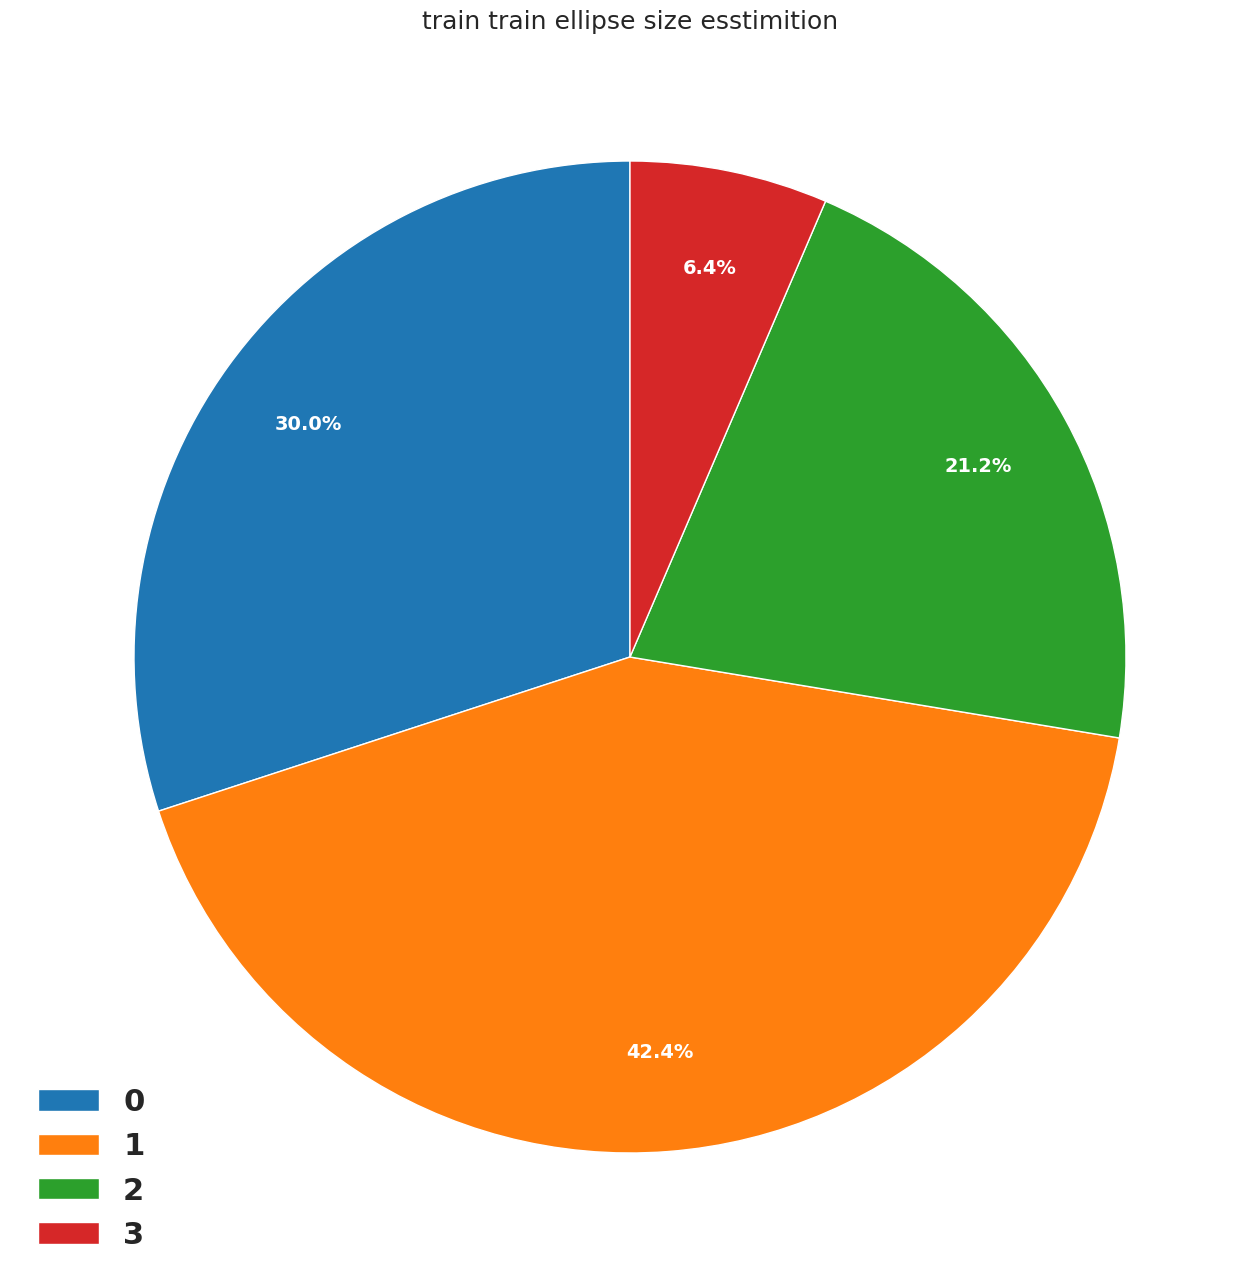

In [7]:

# statistic
generate_data_statistics(X_train_df['ellipse_size_estimiation'].to_list(), plot_dicreption = 'train ellipse size esstimition', data_type = 'train')


## define pre-processing transforms

In [8]:

# get scale operator and apply on training data
scaler_operator = get_normelization_operator(X_train_df, target_columns, target_norm = target_norm)
X_train_df = apply_normelization_on_target(X_train_df, target_columns, scaler_operator)
test_data_df = apply_normelization_on_target(test_data_df, target_columns, scaler_operator)

# set train pre-processing transforms
train_transform = transforms.Compose([
                                       transforms.ToTensor(),
                                       transforms.Normalize(IMAGENET_INCEPTION_MEAN, IMAGENET_INCEPTION_STD) # appply 0-1 normalization 
                                     ])
# set test pre-processing transforms
test_transform = transforms.Compose([
                                        transforms.ToTensor(),
                                        transforms.Normalize(IMAGENET_INCEPTION_MEAN, IMAGENET_INCEPTION_STD) # appply 0-1 normalization 
                                    ])


## split data and generate stats of with\without ellipse

In [9]:

# split into train and validation
X_train_df, X_val_df = train_test_split(X_train_df, stratify =X_train_df['ellipse_size_estimiation'].to_list() ,  test_size=0.2, random_state=42)
X_train_df.sort_index()
X_val_df.sort_index()
test_data_df.sort_index()


,Testing images: is_ellipse,center_x,center_y,angle,axis_1,axis_2,Testing images,is_ellipse,ellipse_size_estimiation
0,images/test/0000.jpg True,0.970588,0.882353,0.894444,0.541667,1.000000,images/test/0000.jpg,True,2.0
1,images/test/0001.jpg True,0.735294,0.911765,0.466667,0.833333,0.833333,images/test/0001.jpg,True,3.0
2,images/test/0002.jpg False,0.000000,0.000000,0.000000,0.000000,0.000000,images/test/0002.jpg,False,0.0
3,images/test/0003.jpg True,0.823529,0.852941,0.300000,0.250000,0.416667,images/test/0003.jpg,True,1.0
4,images/test/0004.jpg False,0.000000,0.000000,0.000000,0.000000,0.000000,images/test/0004.jpg,False,0.0
...,...,...,...,...,...,...,...,...,...
995,images/test/0995.jpg True,0.941176,0.882353,0.411111,0.333333,0.166667,images/test/0995.jpg,True,1.0
996,images/test/0996.jpg True,0.970588,0.794118,0.638889,0.333333,0.166667,images/test/0996.jpg,True,1.0
997,images/test/0997.jpg False,0.000000,0.000000,0.000000,0.000000,0.000000,images/test/0997.jpg,False,0.0
998,images/test/0998.jpg True,0.500000,0.970588,0.055556,0.208333,0.625000,images/test/0998.jpg,True,1.0


## generate statistic for all data-sets
 * note that:
     * 0  - no ellipse
     * 1 - small ellipse
     * 2 - midium ellipse
     * 3 - bigg ellipse

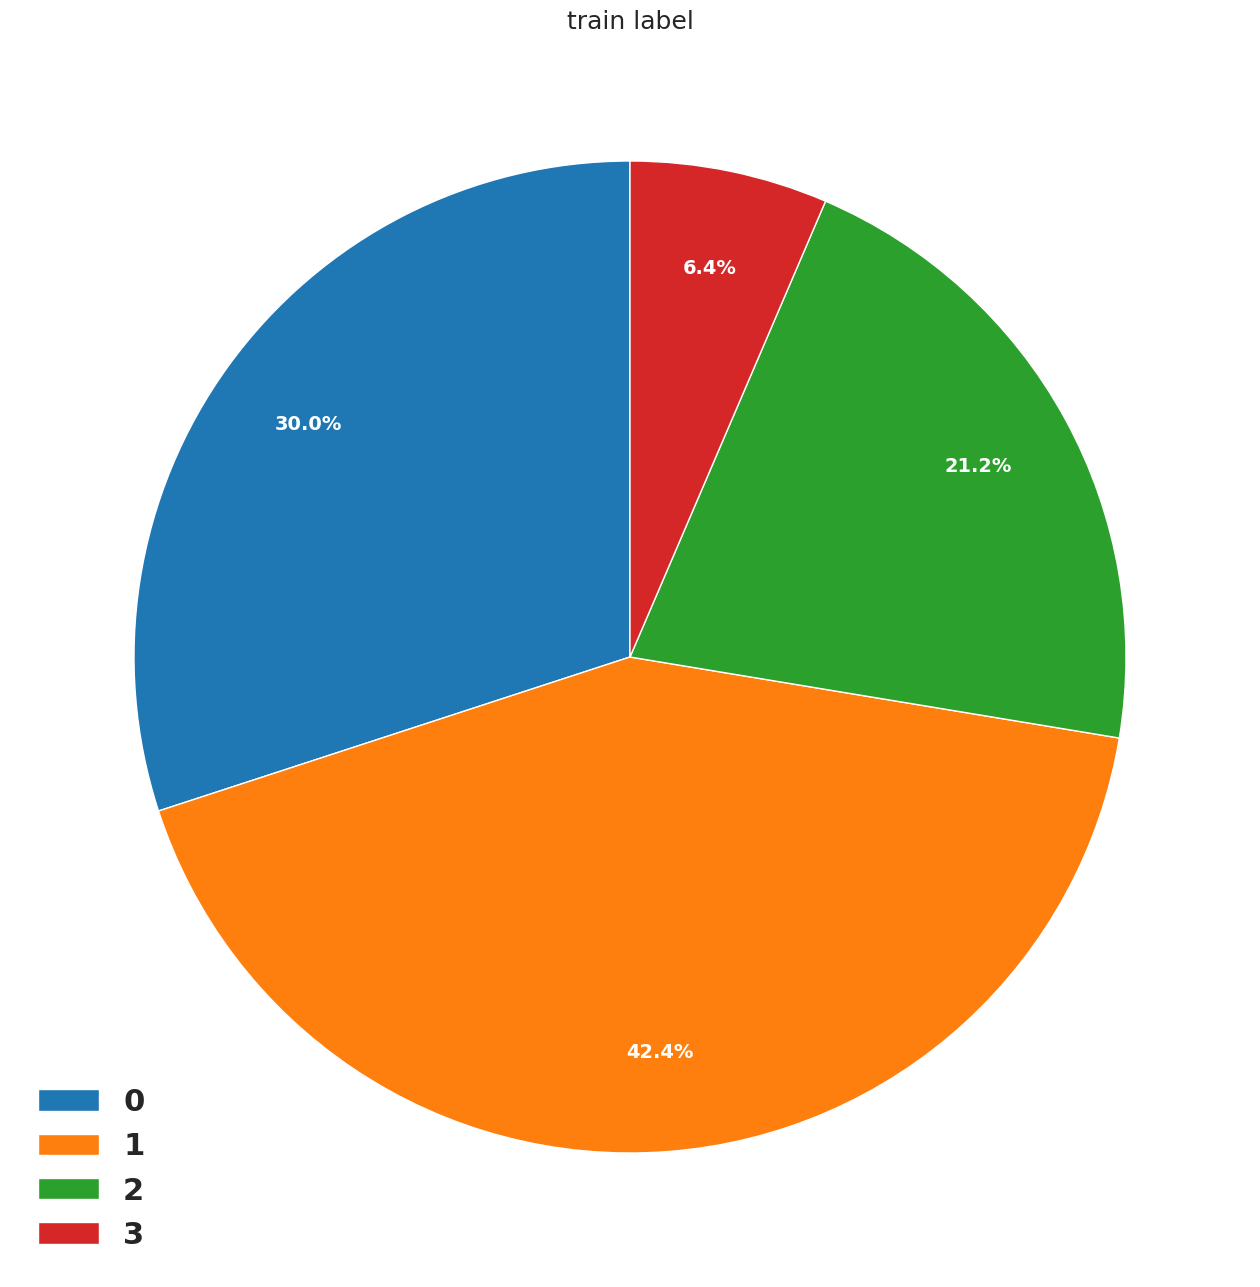

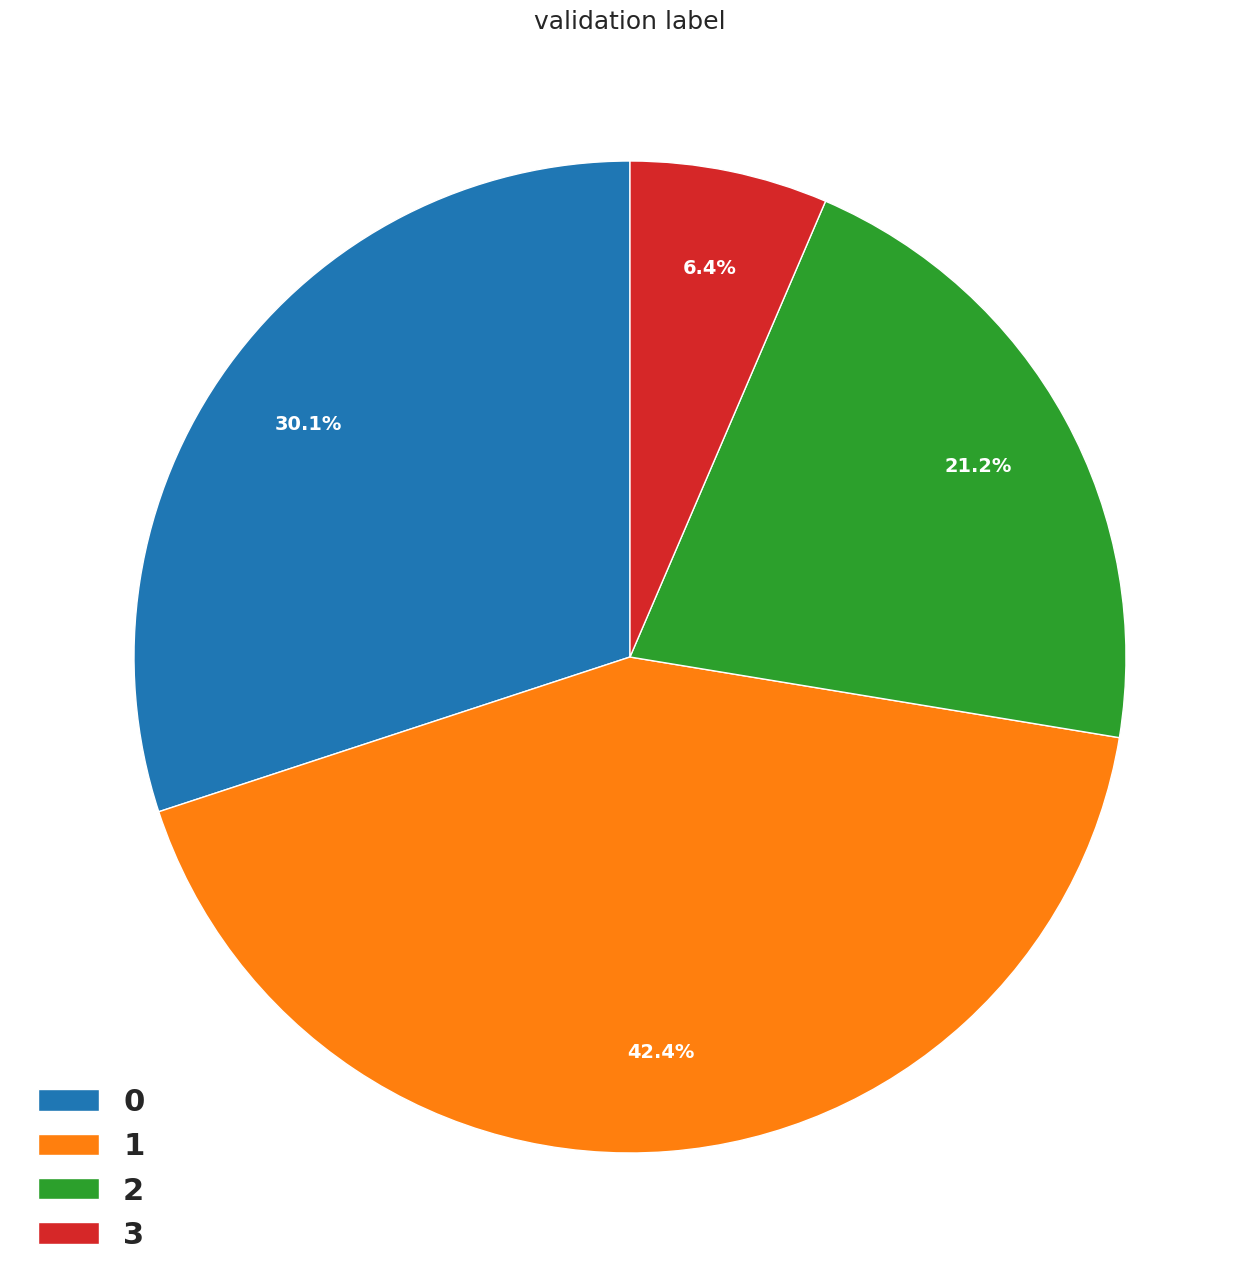

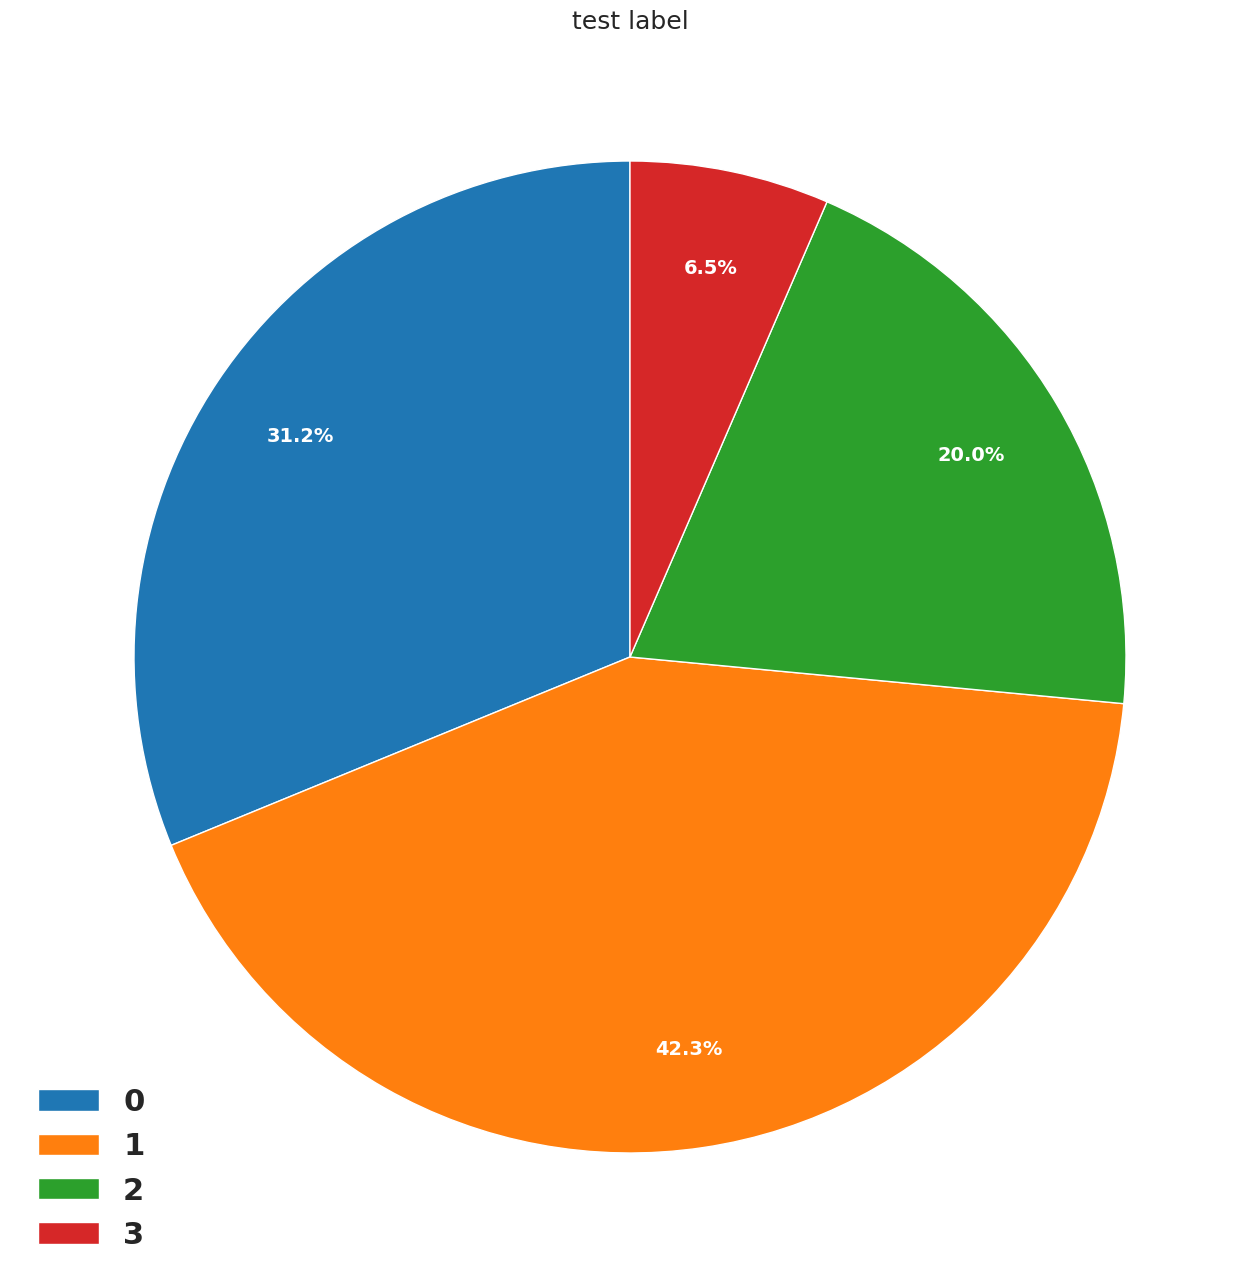

In [11]:

# statistics
generate_data_statistics(X_train_df['ellipse_size_estimiation'].to_list(), plot_dicreption = 'label', data_type = 'train')
generate_data_statistics(X_val_df['ellipse_size_estimiation'].to_list(), plot_dicreption = 'label', data_type = 'validation')
generate_data_statistics(test_data_df['ellipse_size_estimiation'].to_list(), plot_dicreption = 'label', data_type = 'test')


## generate data-sets

In [12]:

# X_train_df = X_train_df[0:5000] # toremove
# get label
class_dict, label_list = generate_label_tesnor_dict(X_val_df)

# generate data sets
X_train = MyDataset(X_train_df, train_transform, test_transform , train = True, ellipse_scale = ellipse_scale, scaler_operator = scaler_operator)
X_val = MyDataset(X_val_df, train_transform, test_transform , train = False, ellipse_scale = ellipse_scale, scaler_operator= scaler_operator)
X_test = MyDataset(X_test_df, train_transform, test_transform , train = False,  debug = False, ellipse_scale = ellipse_scale, scaler_operator = scaler_operator)
X_debug = copy.deepcopy(X_train)
X_train = DataLoader(X_train, batch_size=batch_size, shuffle=True)
X_val = DataLoader(X_val, batch_size=batch_size, shuffle=False)
X_debug = DataLoader(X_debug, batch_size=8, shuffle=False)
X_test = DataLoader(X_test, batch_size=batch_size, shuffle=False)

# set dict of data
data_dict = {'train': X_train, 'val': X_val, 'test': X_test}
data_sizes = {'train': X_train.__len__(), 'val': X_val.__len__(), 'test': X_test.__len__()}

# get amount of labels
amount_of_class = label_list.__len__()

## display input of model

findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.


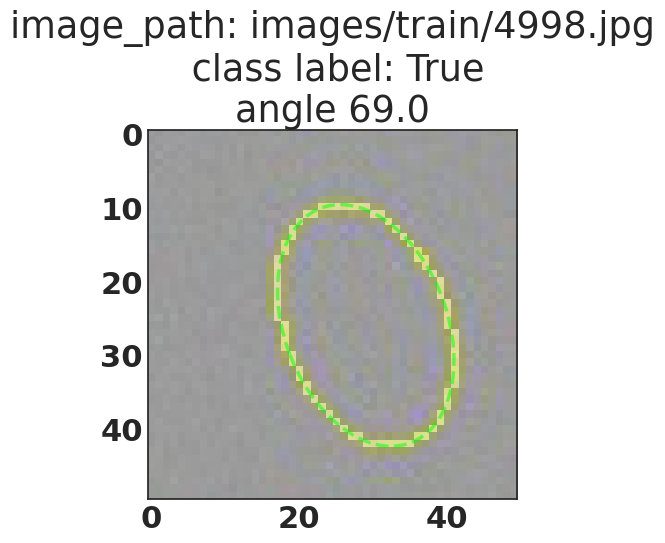

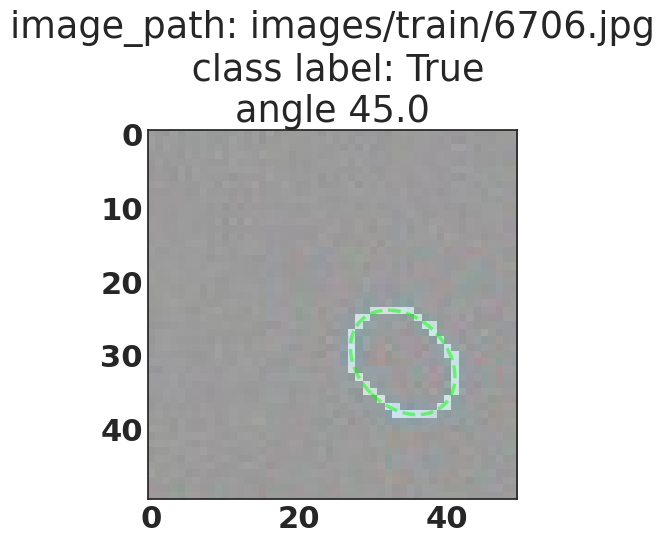

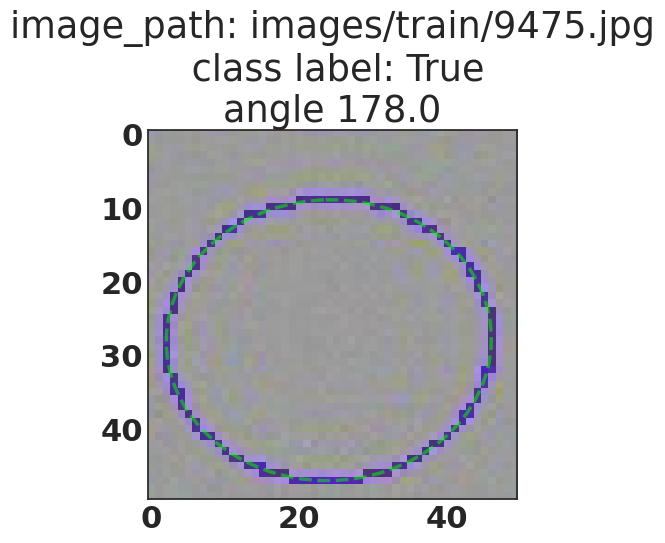

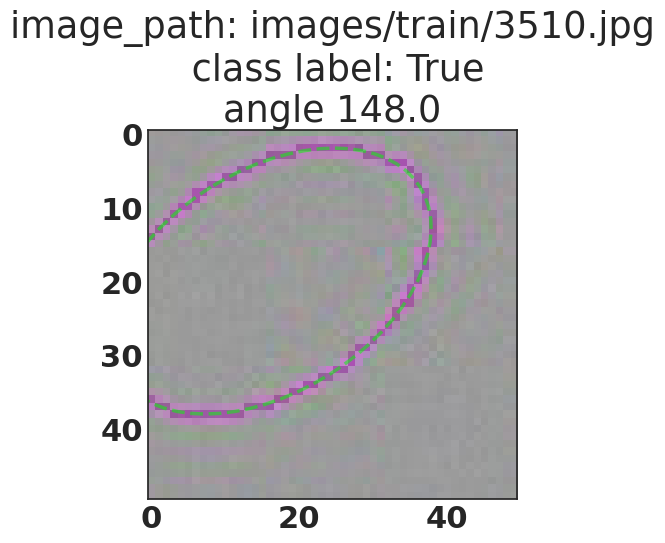

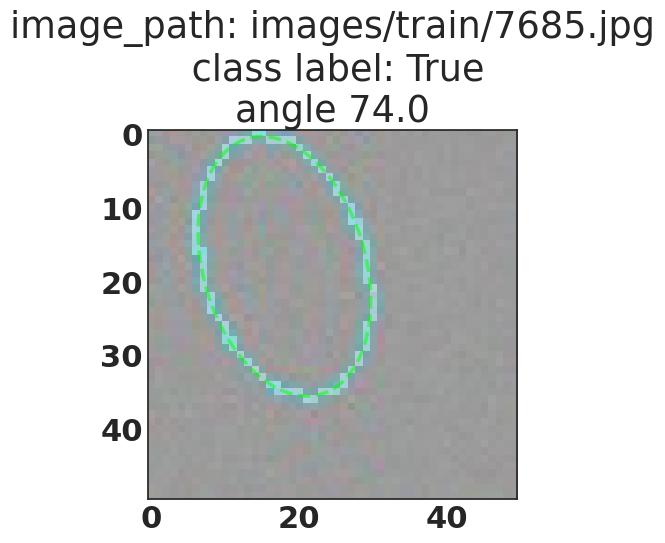

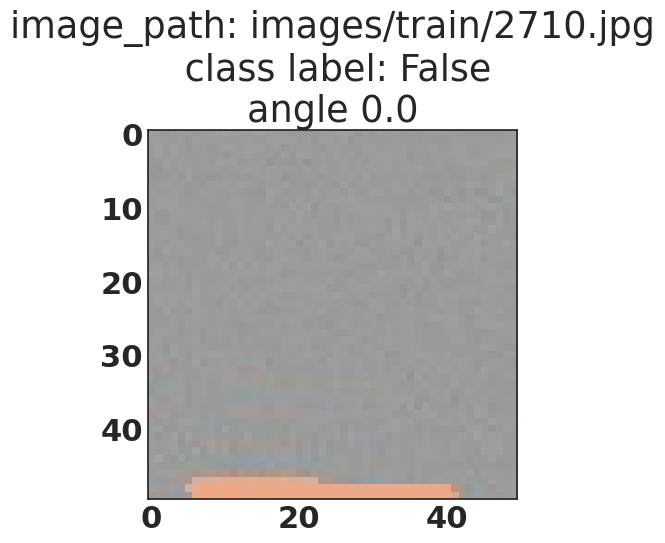

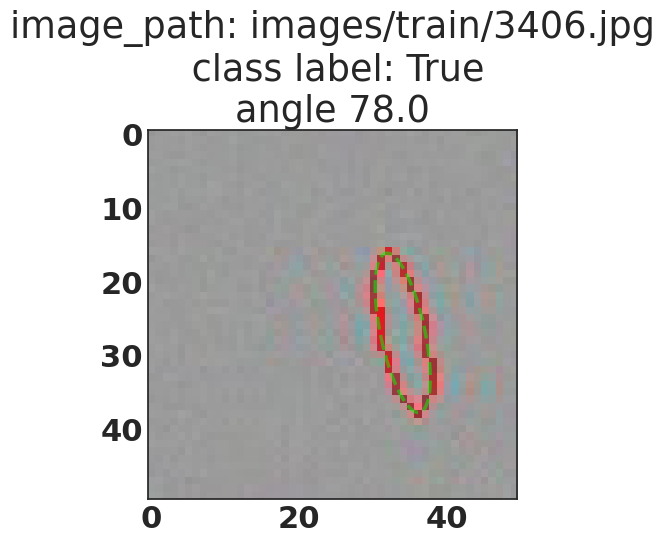

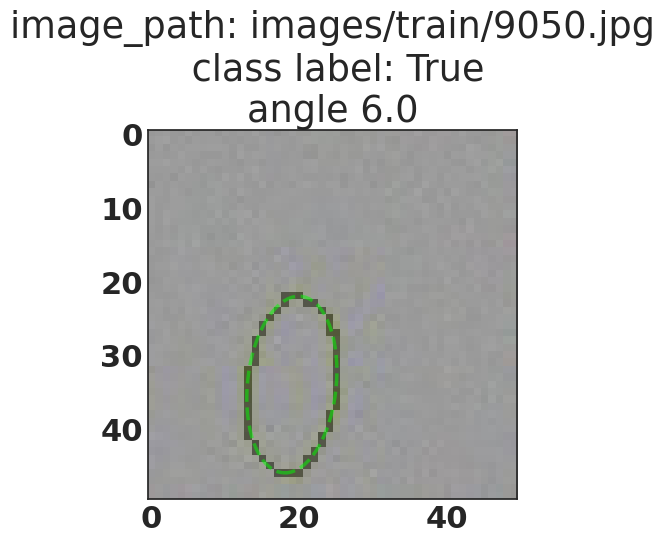

In [13]:
X_debug.dataset.debug = True

# # Display image and label.
for i in range(1):
    train_features, regression_target, label_target, file_name_list = next(iter(X_debug))

# close debug when collect results
X_debug.dataset.debug = False

## load model and set optimizer

In [14]:


# get sizes
batch, channel, height, width = train_features.shape

# set model 
model = EllipseDetectorModel2()
model = model.to(device)

 # set criterion for 2 tasks
criterion_classification = FocalLoss()
criterion_regression = nn.L1Loss()

# set optimization parameters
learning_rate = lr
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.25)

## model summary

In [15]:
summary(model, (channel, height, width))


Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 400]                 --
|    └─Conv2d: 2-1                       [-1, 32, 50, 50]          896
|    └─BatchNorm2d: 2-2                  [-1, 32, 50, 50]          64
|    └─ReLU: 2-3                         [-1, 32, 50, 50]          --
|    └─MaxPool2d: 2-4                    [-1, 32, 25, 25]          --
|    └─Conv2d: 2-5                       [-1, 32, 23, 23]          9,248
|    └─BatchNorm2d: 2-6                  [-1, 32, 23, 23]          64
|    └─ReLU: 2-7                         [-1, 32, 23, 23]          --
|    └─MaxPool2d: 2-8                    [-1, 32, 11, 11]          --
|    └─Conv2d: 2-9                       [-1, 16, 11, 11]          528
|    └─BatchNorm2d: 2-10                 [-1, 16, 11, 11]          32
|    └─ReLU: 2-11                        [-1, 16, 11, 11]          --
|    └─MaxPool2d: 2-12                   [-1, 16, 5, 5]            --
|    └─Fla

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 400]                 --
|    └─Conv2d: 2-1                       [-1, 32, 50, 50]          896
|    └─BatchNorm2d: 2-2                  [-1, 32, 50, 50]          64
|    └─ReLU: 2-3                         [-1, 32, 50, 50]          --
|    └─MaxPool2d: 2-4                    [-1, 32, 25, 25]          --
|    └─Conv2d: 2-5                       [-1, 32, 23, 23]          9,248
|    └─BatchNorm2d: 2-6                  [-1, 32, 23, 23]          64
|    └─ReLU: 2-7                         [-1, 32, 23, 23]          --
|    └─MaxPool2d: 2-8                    [-1, 32, 11, 11]          --
|    └─Conv2d: 2-9                       [-1, 16, 11, 11]          528
|    └─BatchNorm2d: 2-10                 [-1, 16, 11, 11]          32
|    └─ReLU: 2-11                        [-1, 16, 11, 11]          --
|    └─MaxPool2d: 2-12                   [-1, 16, 5, 5]            --
|    └─Fla

In [16]:

model.softmax(model.sigma)

tensor([0.3333, 0.3333, 0.3333], grad_fn=<SoftmaxBackward0>)

## train model

In [17]:

# get start training time
since = time.time()

# set model weight before the training
best_model_wts = copy.deepcopy(model.state_dict())

# clean cash
gc.collect()

# set empty list for loss as function of ephocs
loss_batch_list = []

# set high loss val for updating best model
best_loss = 1e5

# set the amount of ephocs
num_epochs = 150

# set max patient without change in best loss
max_patience = 20
patience_trainning_idx = 1

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    print('-' * 10)
    gc.collect()

    # Each epoch has a training and validation phase
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()  # Set model to training mode
        else:
            model.eval()   # Set model to evaluate mode

        i_data_size = data_sizes[phase]
        ephoc_loss_rate = 0.0

        # Iterate over data.
        for inputs, regression_target, label_target, file_name_list in data_dict[phase]:
            # send to device input & targets
            inputs = inputs.to(device)
            regression_target = regression_target.to(device)
            label_target = label_target.to(device)


            # forward
            with torch.set_grad_enabled(phase == 'train'):
                # class_pred, reg_pred  = model(inputs)

                # model prediction and get label pred
                regression_pred, label_pred = model(inputs)

                # get loss
                batch_loss = calculate_loss(model, regression_target, label_target, file_name_list, regression_pred, label_pred, criterion_regression, criterion_classification)

                # backward + optimize only if in training phase
                if phase == 'train':
                    # update model
                    optimizer.zero_grad()
                    batch_loss.backward()
                    optimizer.step()

                    debug_predict = False
                    debug_grad = False
                    # in order to investigate prediction on
                    if debug_predict:
                        model, val_loss_rate = predict(model, data_sizes, data_dict, scaler_operator, criterion_regression, criterion_classification, device,  phase ='val', debug = True)

                    if debug_grad: # if needed desire to investigate gradient
                        for param in model.named_parameters():
                            print(torch.max(torch.abs(param[1].grad)))

            # get current batch size
            batch_size = inputs.shape[0]

            # get batch loss rate
            batch_loss_mse_rate = batch_loss.item()

            # sum aphoc loss rate
            ephoc_loss_rate += batch_loss_mse_rate*batch_size

        # update learning rate base the condition
        if phase == 'train':
            scheduler.step()

        # calculate ephoc loss and append results
        epoch_loss = ephoc_loss_rate / i_data_size
        loss_batch_list.append(epoch_loss)
        print(f'{phase} Loss : {epoch_loss:.4f}')

        # deep copy the model
        if phase == 'val' and epoch_loss <  best_loss:
            # itiate patience index
            patience_trainning_idx = 0

            # update best loss
            best_loss = epoch_loss

            # copy weights
            best_model_wts = copy.deepcopy(model.state_dict())

            # save weights
            torch.save(best_model_wts, weights_path)

        # stop training because of model is stuck

    patience_trainning_idx += 1
    if patience_trainning_idx > max_patience:
        print(f'stop training because best loss dosnot change for {max_patience} ephocs')
        break


time_elapsed = time.time() - since
print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
print(f'Best val loss: {best_loss:4f}')

Epoch 1/150
----------
train Loss : 0.6934
val Loss : 0.4210
Epoch 2/150
----------
train Loss : 0.3849
val Loss : 0.2884
Epoch 3/150
----------
train Loss : 0.2723
val Loss : 0.2333
Epoch 4/150
----------
train Loss : 0.2168
val Loss : 0.1926
Epoch 5/150
----------
train Loss : 0.1950
val Loss : 0.1661
Epoch 6/150
----------
train Loss : 0.1762
val Loss : 0.2142
Epoch 7/150
----------
train Loss : 0.1629
val Loss : 0.1629
Epoch 8/150
----------
train Loss : 0.1569
val Loss : 0.1382
Epoch 9/150
----------
train Loss : 0.1502
val Loss : 0.1475
Epoch 10/150
----------
train Loss : 0.1433
val Loss : 0.1809
Epoch 11/150
----------
train Loss : 0.1156
val Loss : 0.1228
Epoch 12/150
----------
train Loss : 0.1112
val Loss : 0.1152
Epoch 13/150
----------
train Loss : 0.1079
val Loss : 0.1136
Epoch 14/150
----------
train Loss : 0.1064
val Loss : 0.1136
Epoch 15/150
----------
train Loss : 0.1036
val Loss : 0.1124
Epoch 16/150
----------
train Loss : 0.1018
val Loss : 0.1154
Epoch 17/150
----

## display loss converge

findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.


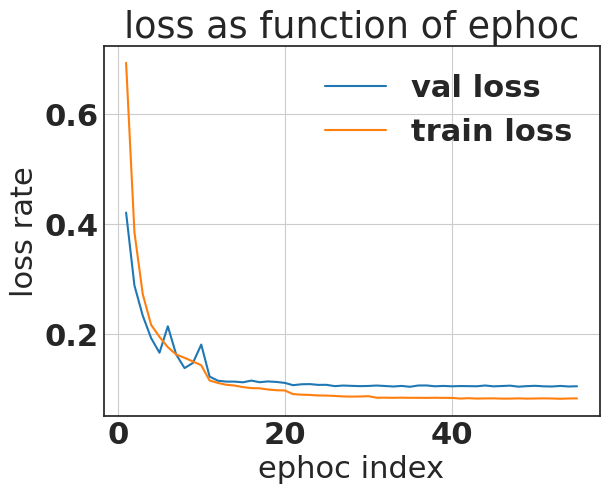

In [18]:
display_loss_converge(loss_batch_list)


## run model on train, validation, test

## load best model and evaluate validation

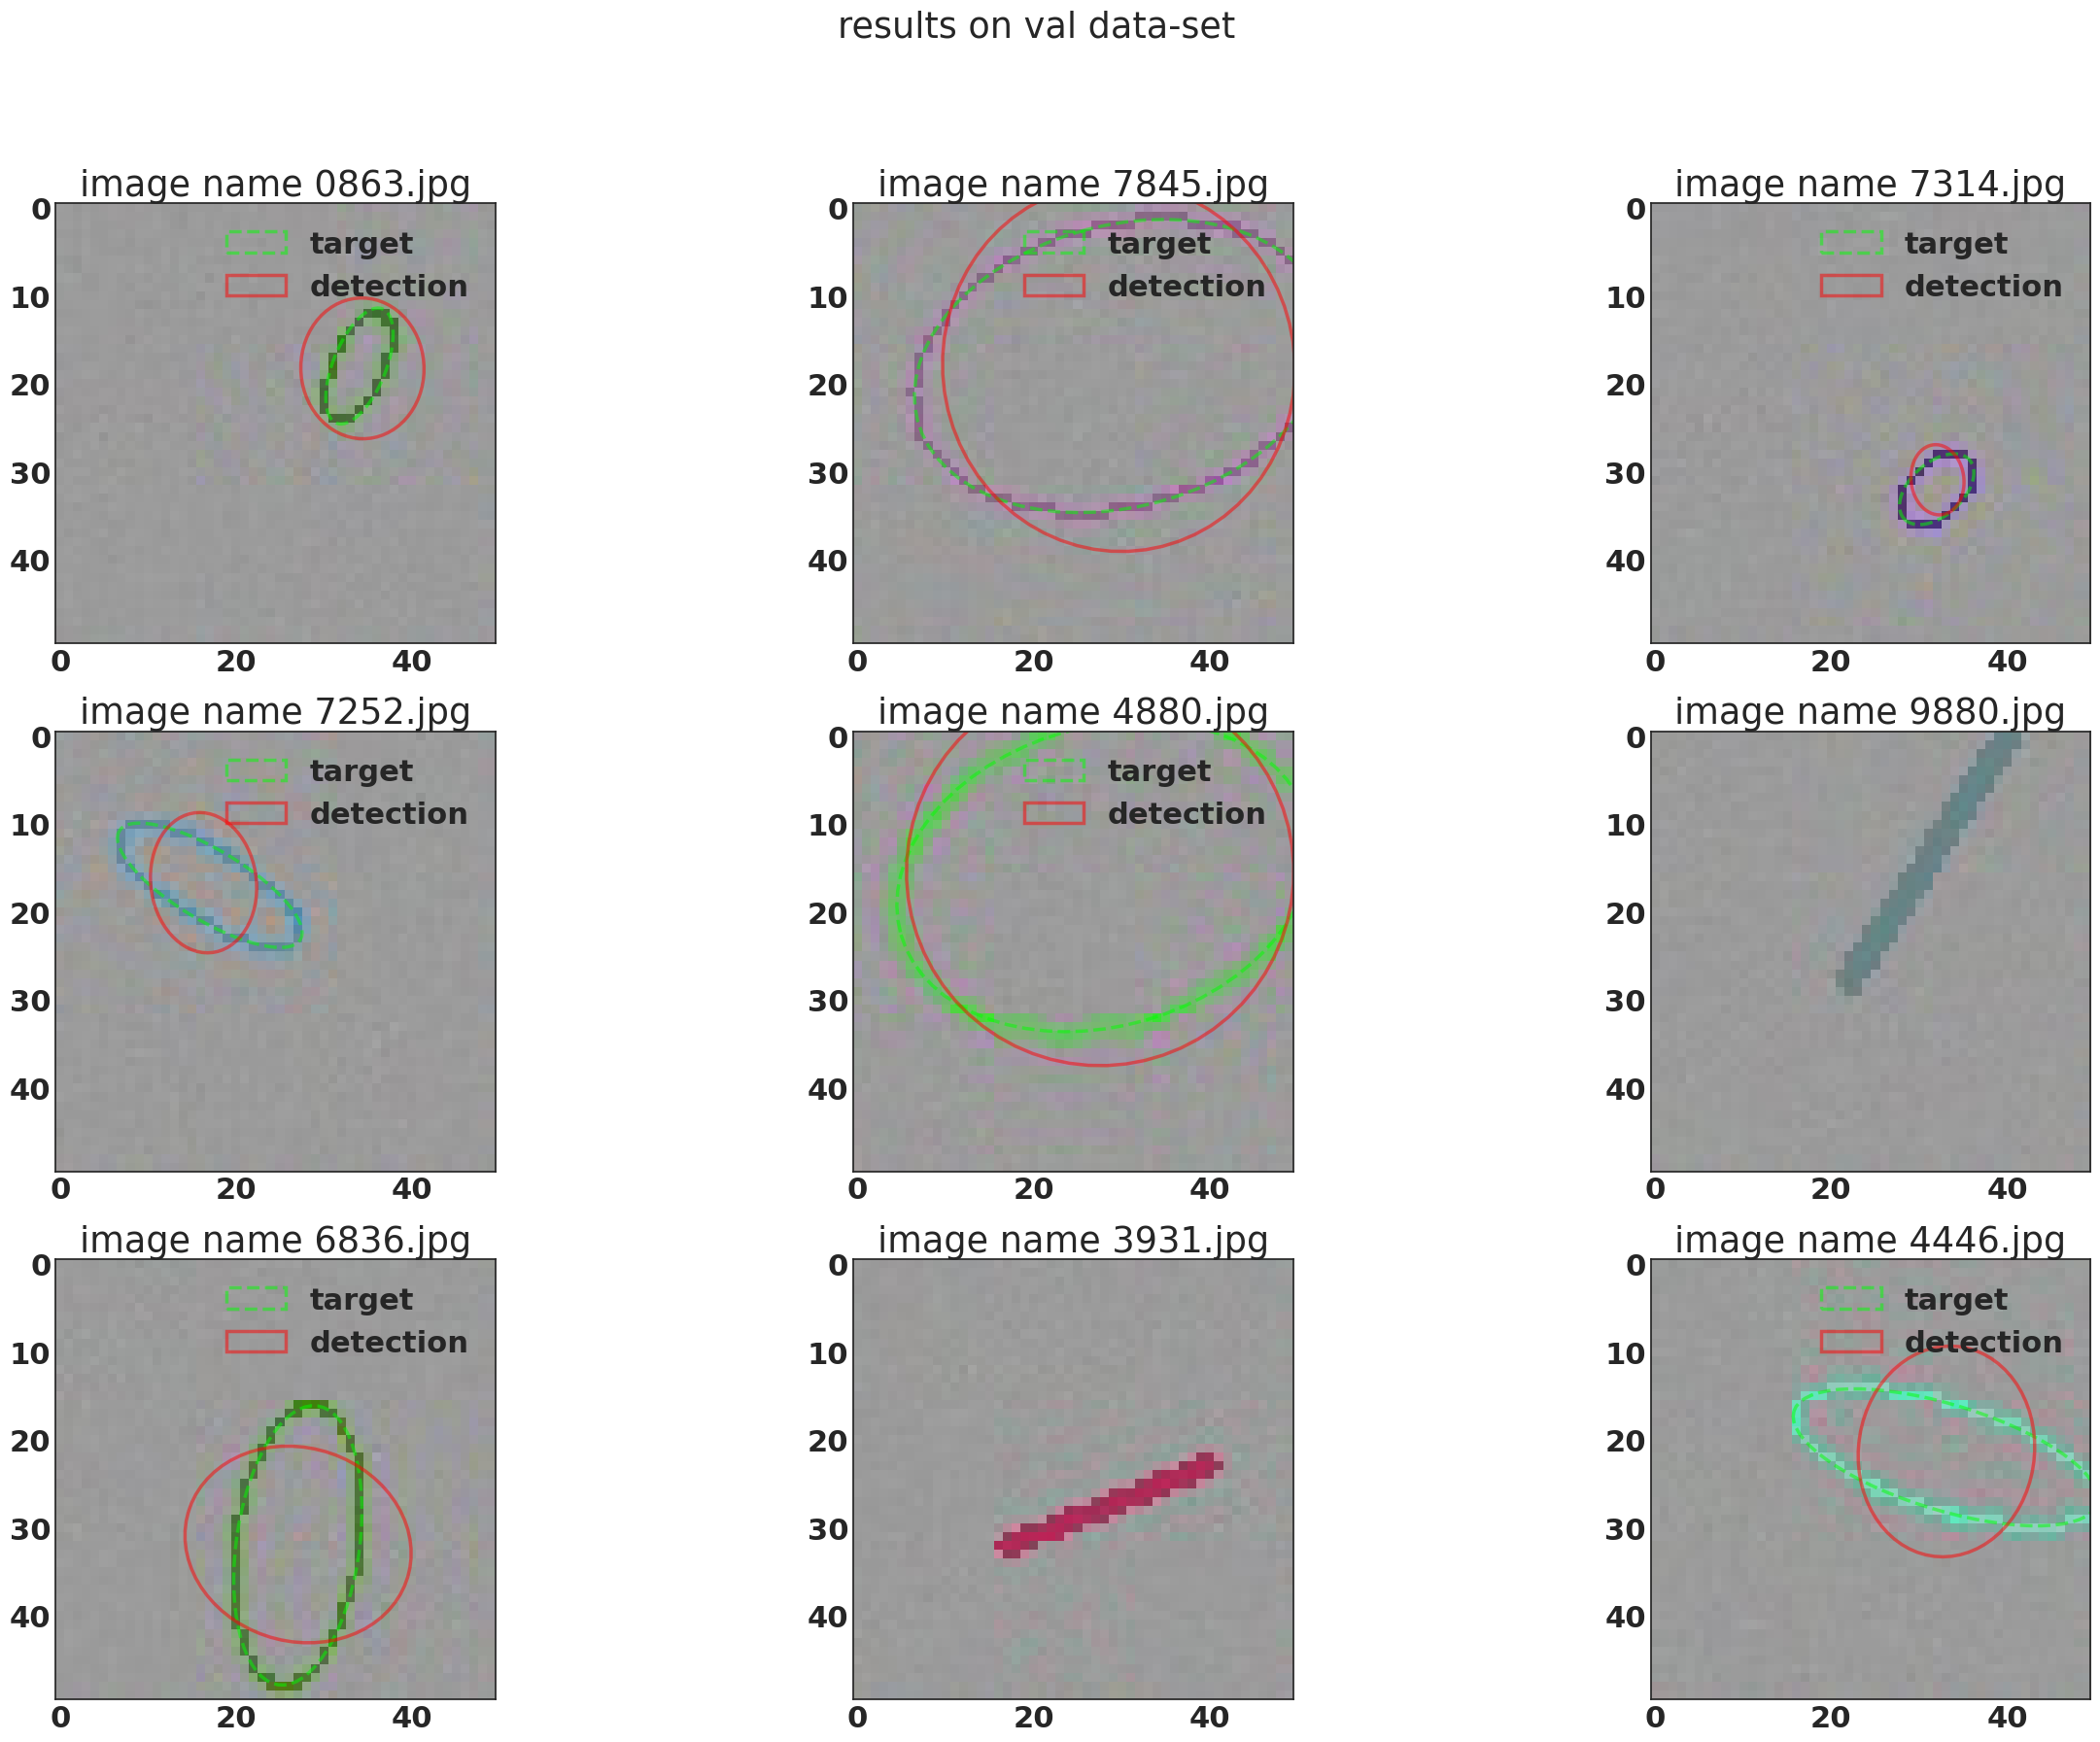

In [19]:

# load best model weights
model.load_state_dict(best_model_wts)


# calculate results on data
model, val_loss_rate, val_results = predict(model, data_sizes, data_dict, scaler_operator, criterion_regression, criterion_classification, device,  phase ='val', debug = True)


## evaluate train

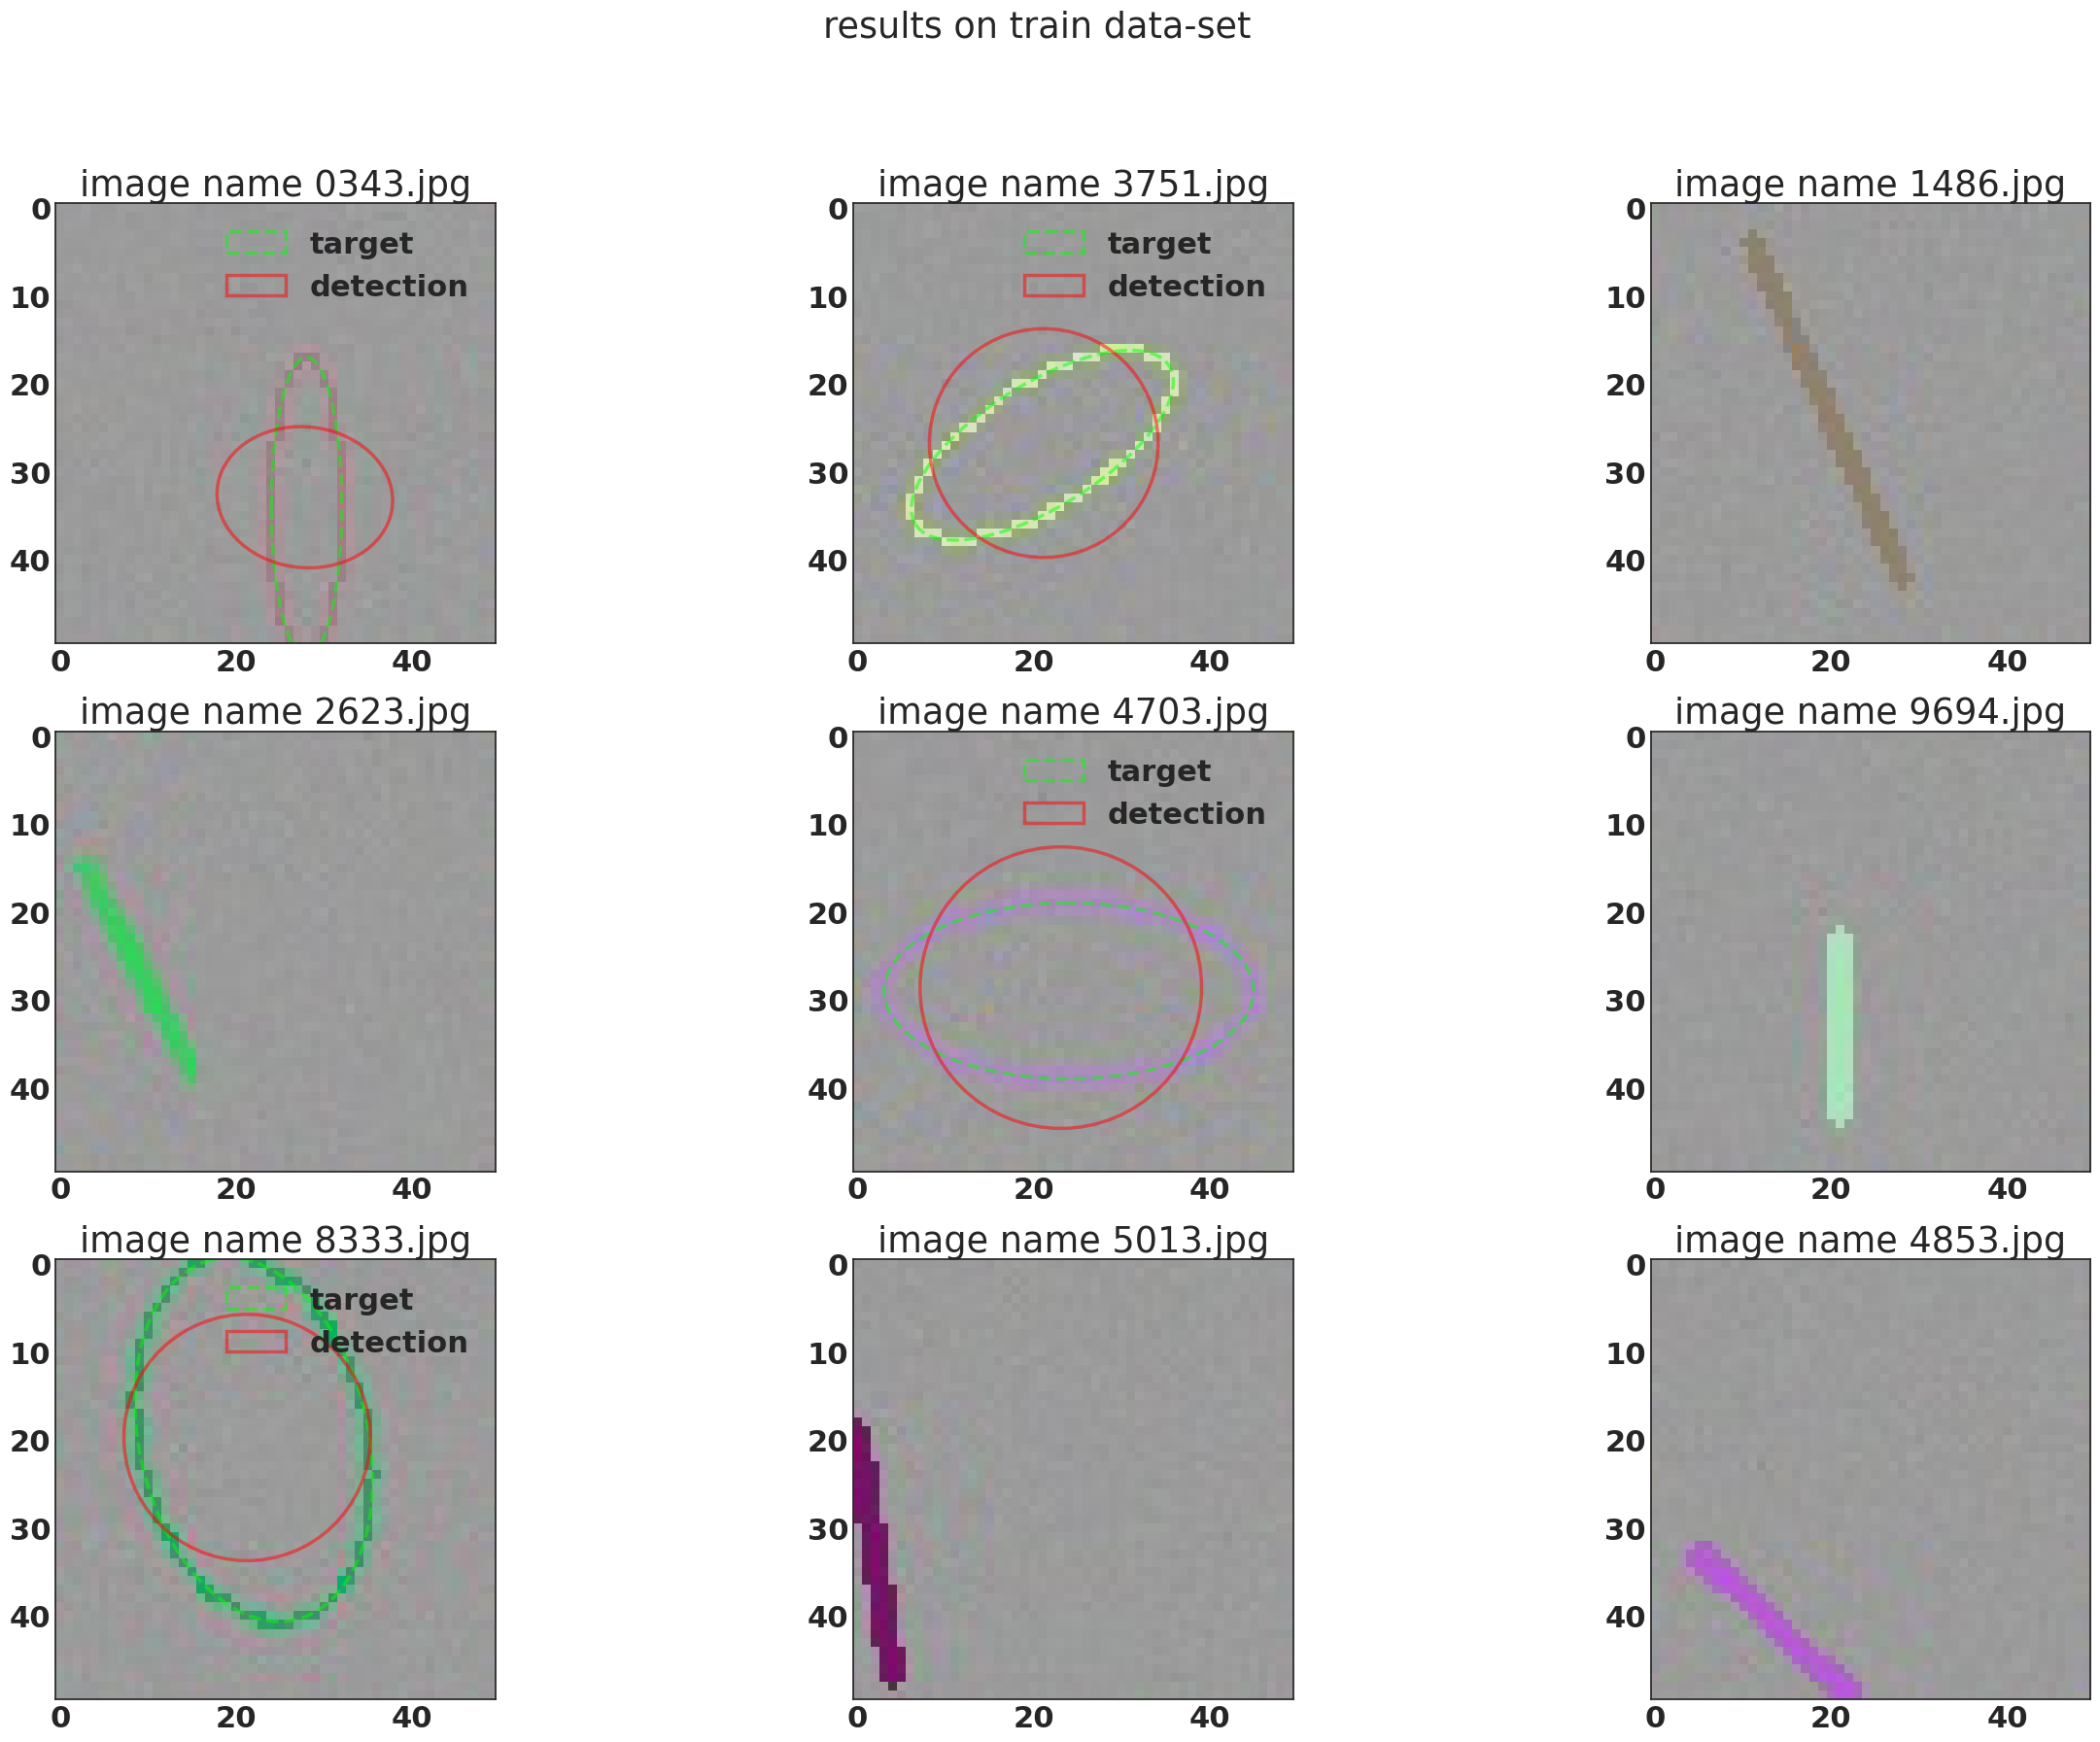

In [20]:
model, train_loss_rate, train_results = predict(model, data_sizes, data_dict, scaler_operator, criterion_regression, criterion_classification, device,  phase ='train', debug = True)


## evaluate test

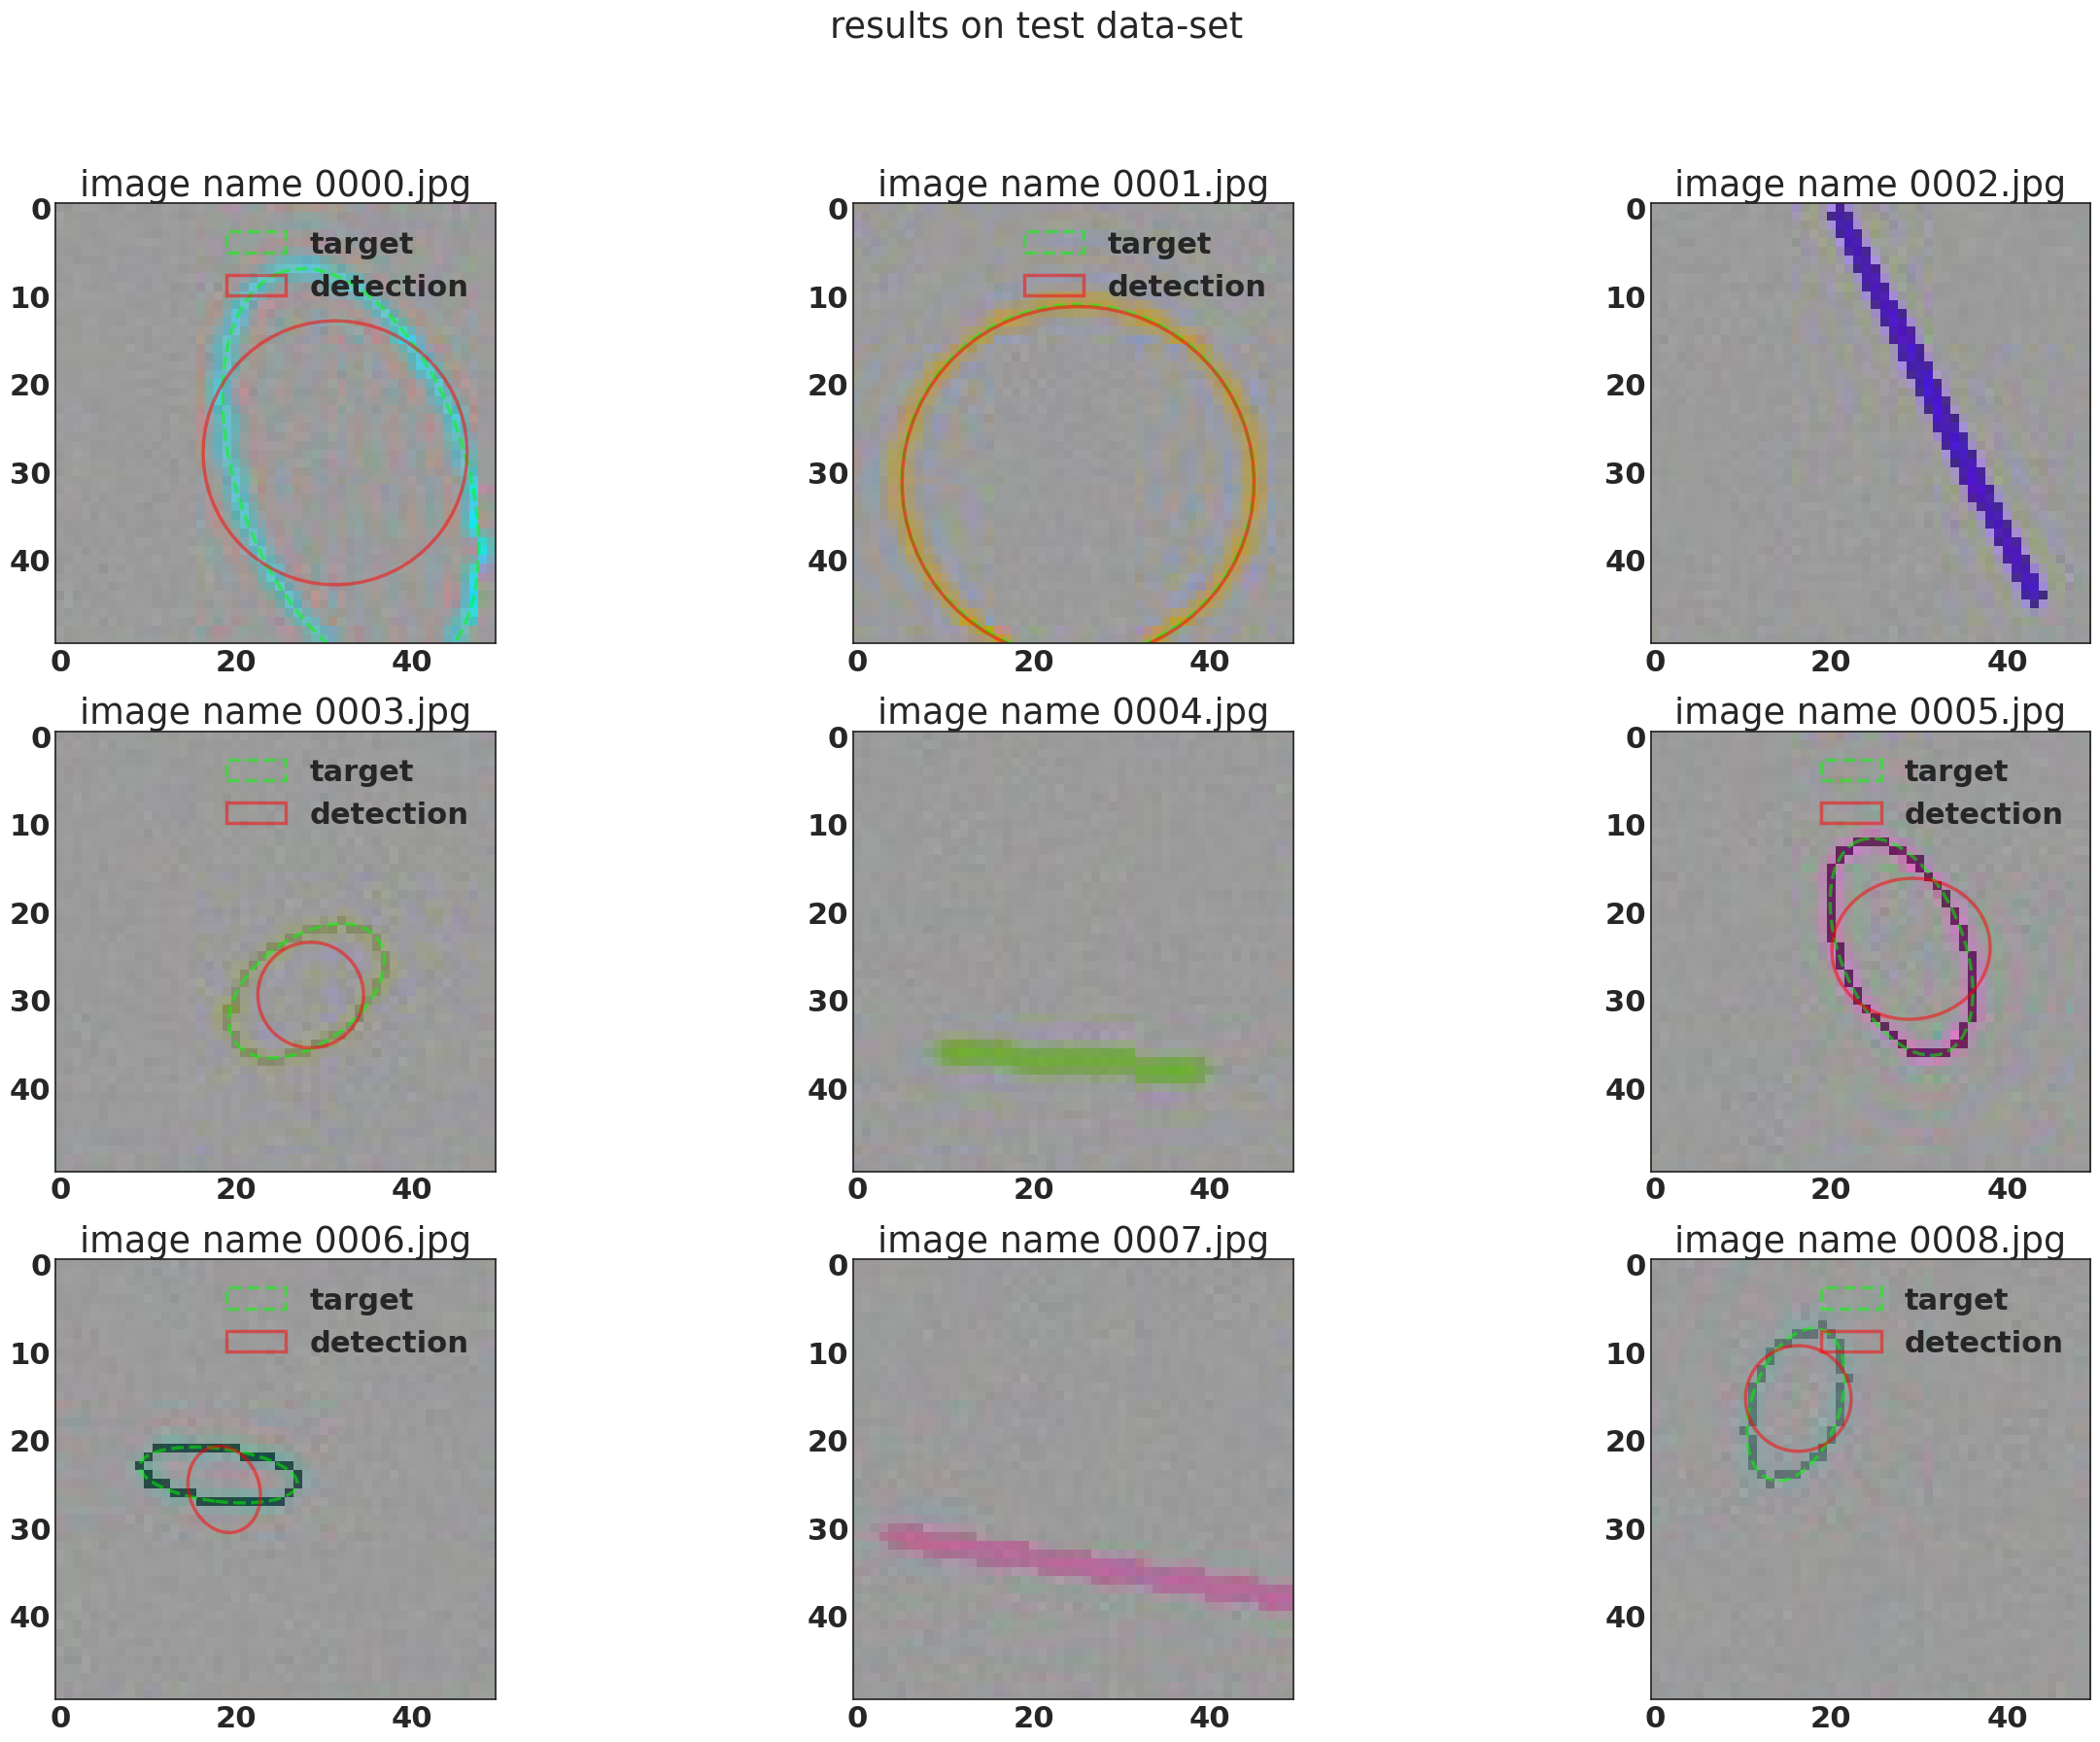

In [21]:
model, test_loss_rate, test_results = predict(model, data_sizes, data_dict, scaler_operator, criterion_regression, criterion_classification, device,  phase ='test', debug = True)


## display results

In [22]:
# diplay results
results_df =  pd.DataFrame([[train_loss_rate, val_loss_rate, test_loss_rate]], columns = ['train_loss_rate', 'val_loss_rate', 'test_loss_rate'])

print(f'loss results on test data {test_loss_rate}')
results_df.head()


loss results on test data 0.10923503324389458


,train_loss_rate,val_loss_rate,test_loss_rate
0,0.078201,0.104246,0.109235


## display confusion matrix 

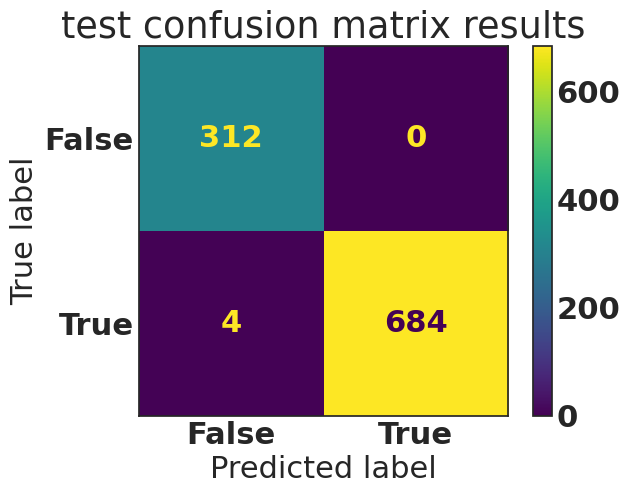

In [23]:
confusion_matrix = display_confusion_matrix(test_results, 'test')


## display test calssification errors
   * the goal is to see that the label data is not perfect labeled

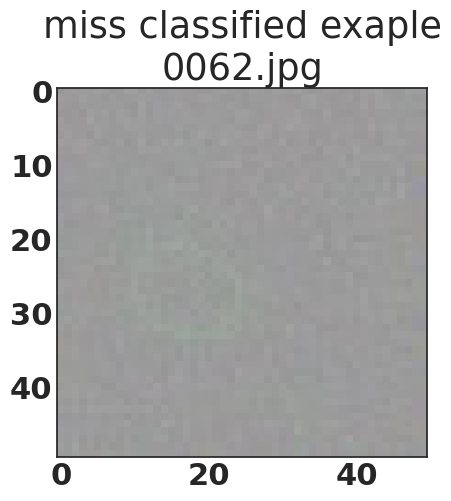

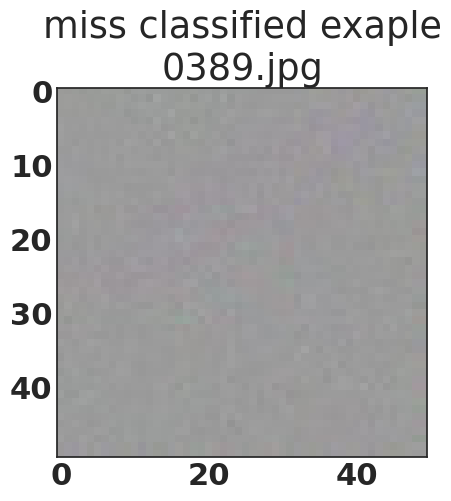

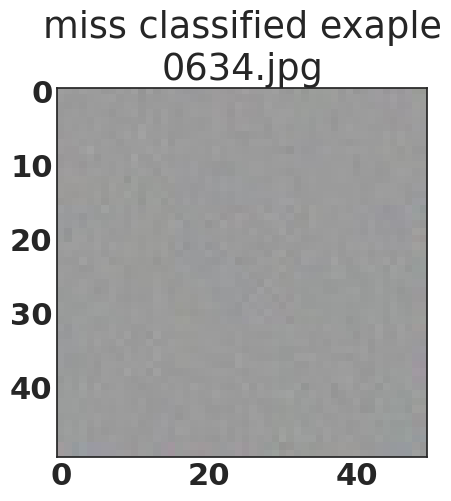

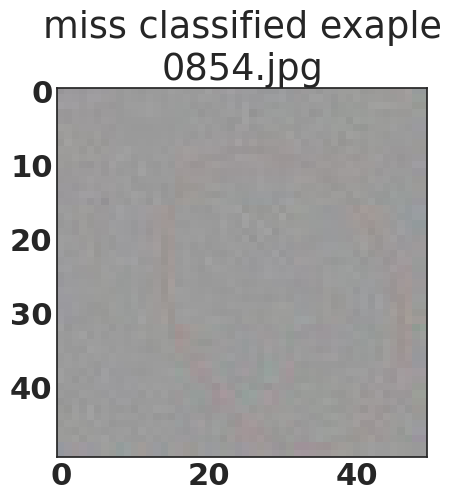

In [24]:
display_predictions_errors(test_results)



## display test calssification train
   * the goal is to see that the label data is not perfect labeled

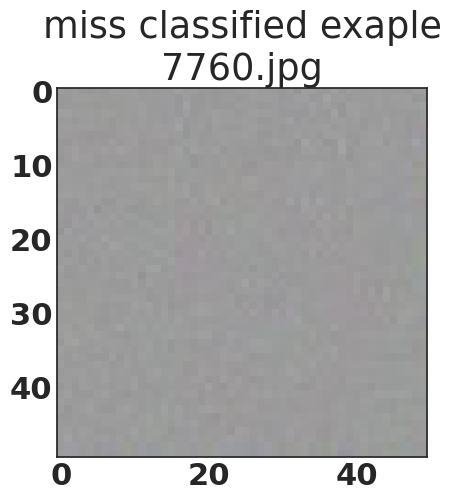

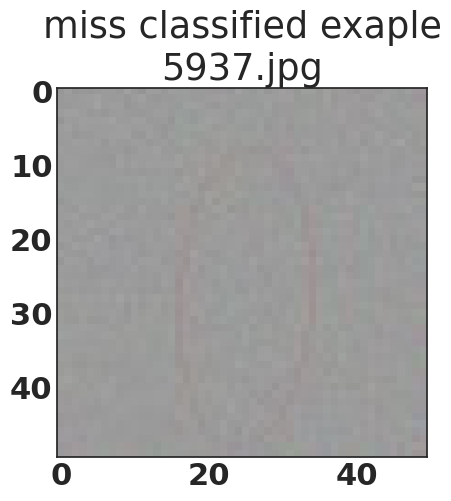

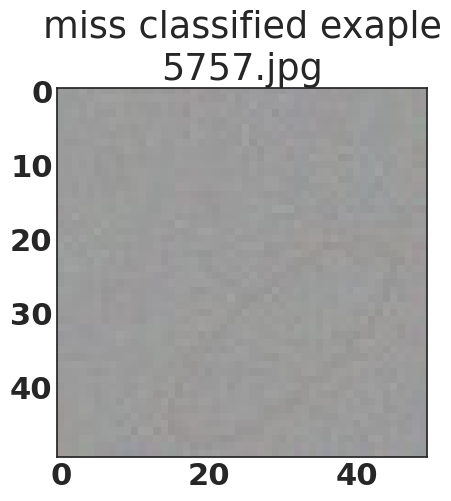

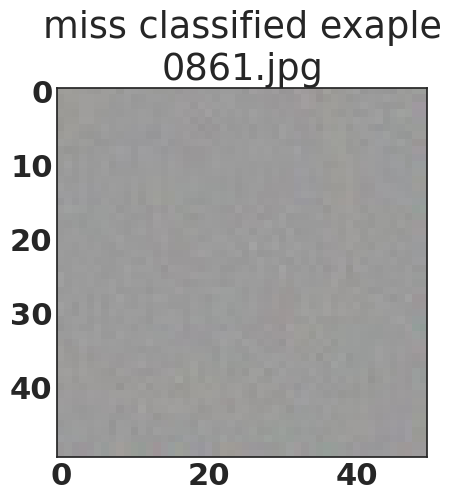

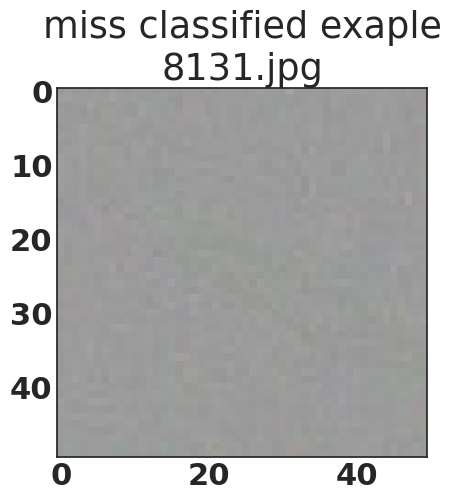

In [25]:
display_predictions_errors(train_results)

In [26]:
model.softmax(model.sigma)

tensor([1.0706e-05, 1.0322e-05, 9.9998e-01], grad_fn=<SoftmaxBackward0>)